In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,auc,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,precision_recall_curve,classification_report,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [ ]:
def eda(df):

    print("DATASET INFORMATION")

    print("\nShape:", df.shape)

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())
    print("\nDataset Overview")
    print(df.info())

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values Before Cleaning")
    print(df.isnull().sum())

    print("\nDuplicate Rows Before Cleaning:", df.duplicated().sum())

    print("\nSummary Statistics")
    print(df.describe(include="all"))

    print("\nUnique Values")
    for col in df.columns:
        print(col, ":", df[col].nunique())

    for col in df.columns:
        if col == "class":
            df[col] = df[col].fillna(df[col].mode()[0])
        elif df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

    print("\nMissing Values After Cleaning")
    print(df.isnull().sum())

    print("\nDuplicate Rows Before Removal:", df.duplicated().sum())

    df.drop_duplicates(inplace=True)

    print("Duplicate Rows After Removal:", df.duplicated().sum())

    encoder = LabelEncoder()

    for col in df.select_dtypes(include="object").columns:
        df[col] = encoder.fit_transform(df[col])

    numeric = df.select_dtypes(include=np.number).columns

    for col in numeric:
        if col != "class":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)

            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            df = df[(df[col] >= lower) & (df[col] <= upper)]

    print("\nShape After Removing Outliers:", df.shape)

    df[numeric].hist(figsize=(18,18))
    plt.suptitle("Histograms")
    plt.show()

    for col in numeric:
        plt.figure(figsize=(6,4))
        plt.boxplot(df[col])
        plt.title(col)
        plt.show()

    for col in df.columns:
        if df[col].nunique() < 15:
            plt.figure(figsize=(6,4))
            df[col].value_counts().plot(kind="bar")
            plt.title(col)
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.show()

    corr = df[numeric].corr()

    plt.figure(figsize=(16,14))
    plt.imshow(corr, cmap="coolwarm")
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
    plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)

    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            plt.text(j, i, round(corr.iloc[i, j], 2),
                     ha="center",
                     va="center",
                     fontsize=5)

    plt.title("Correlation Heatmap")
    plt.show()

    scaler = MinMaxScaler()

    X = df.drop("class", axis=1)
    y = df["class"]

    X = scaler.fit_transform(X)

    X = pd.DataFrame(X, columns=df.columns[:-1])

    df = X.copy()
    df["class"] = y

    print("\nNormalization Completed Successfully")

    return df

DATASET INFORMATION

Shape: (4621, 58)

First 5 Rows
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             

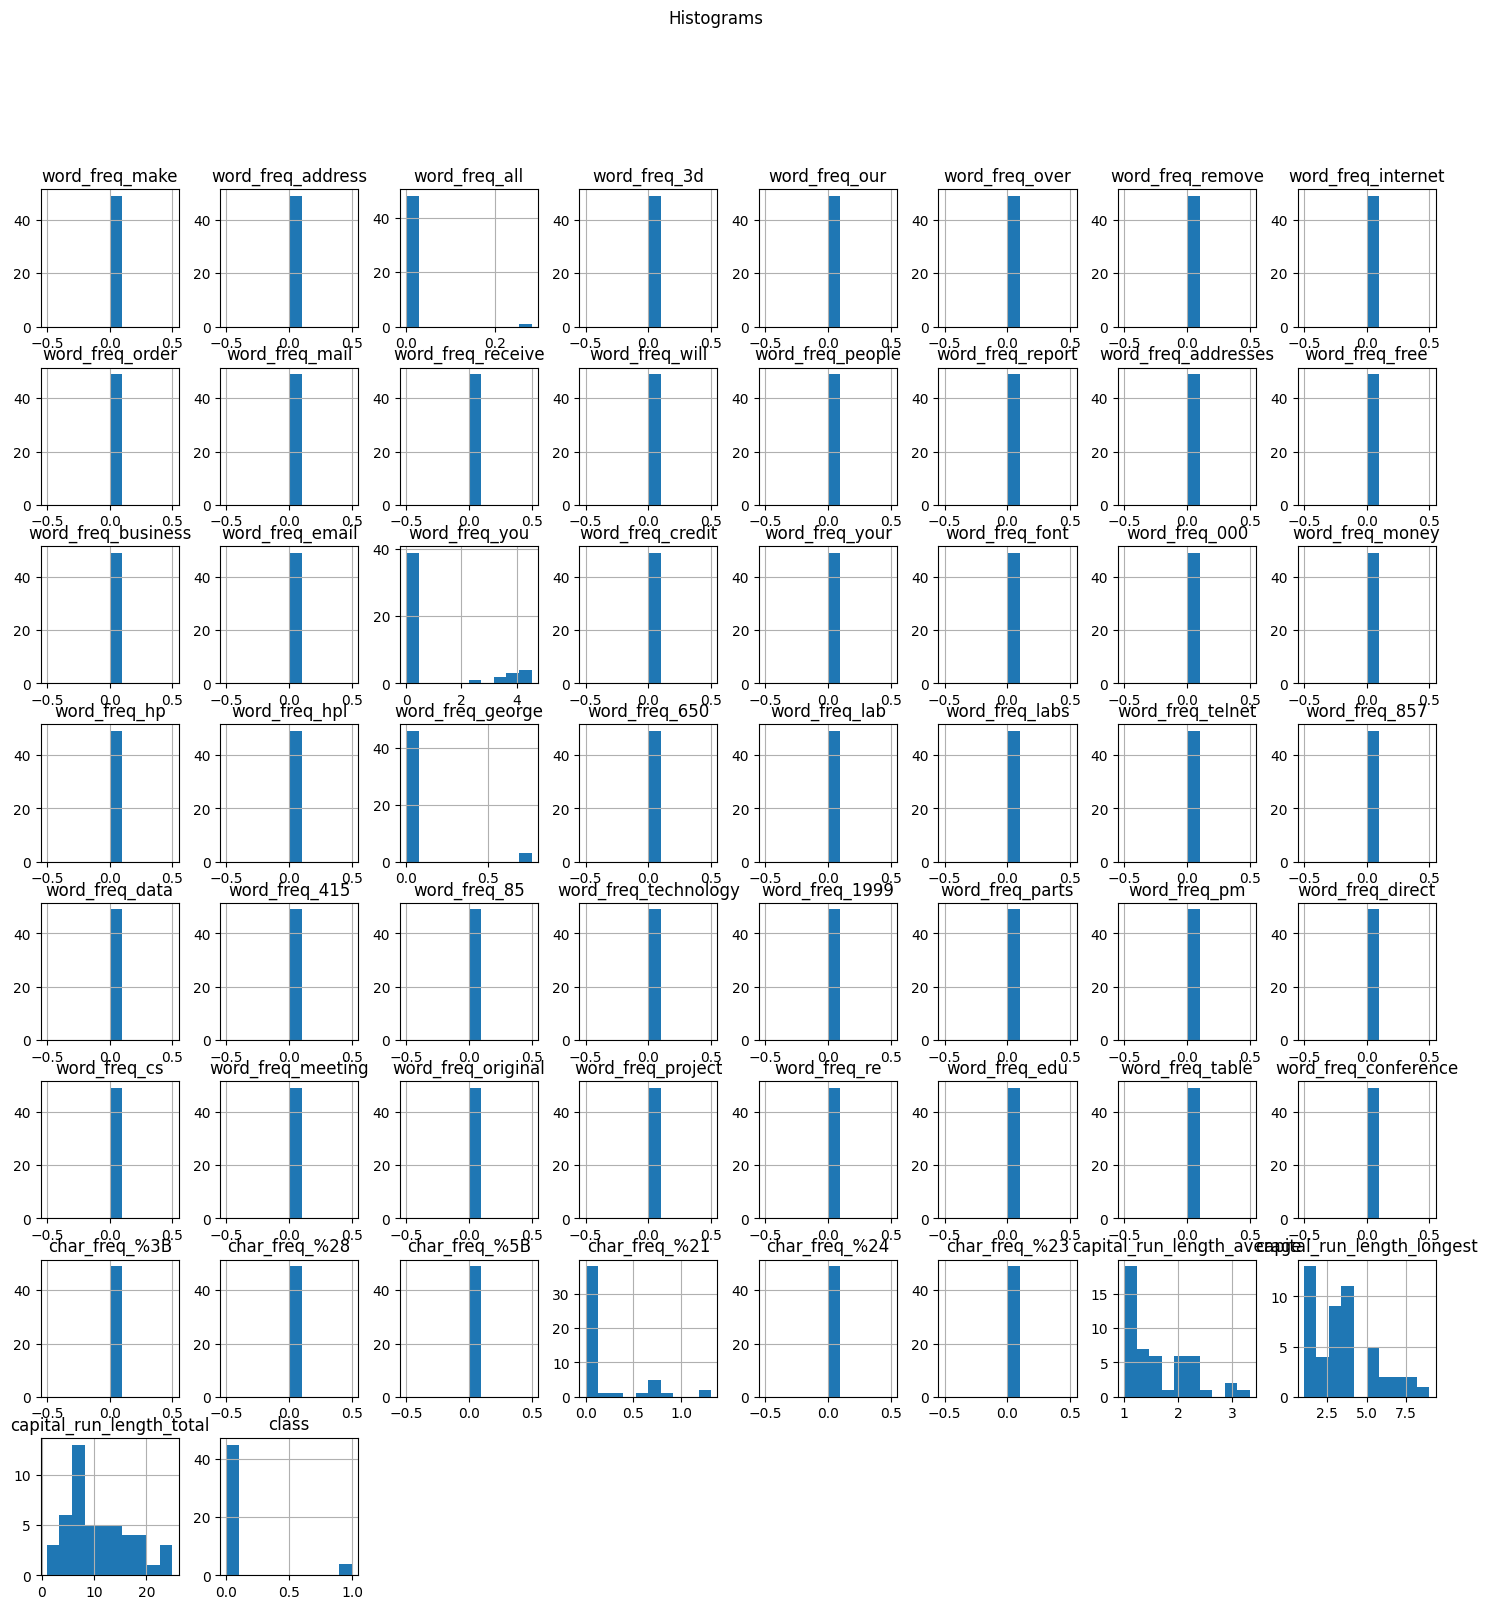

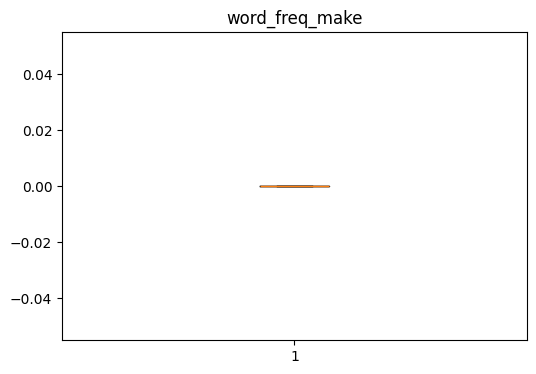

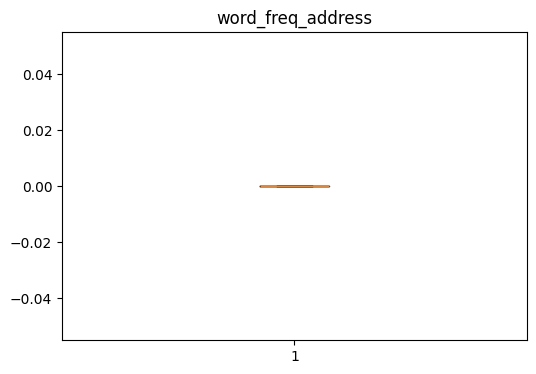

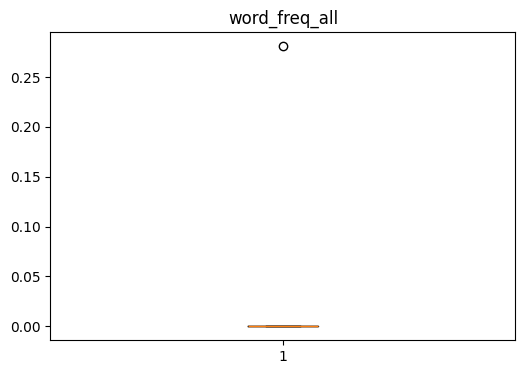

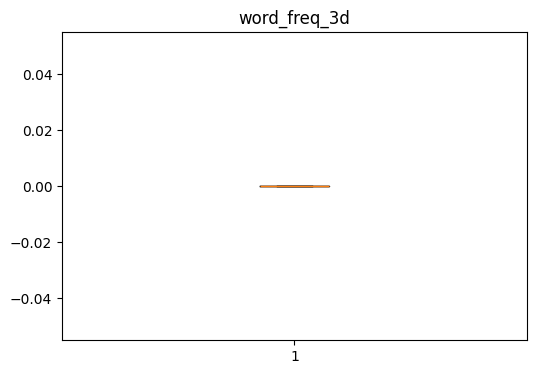

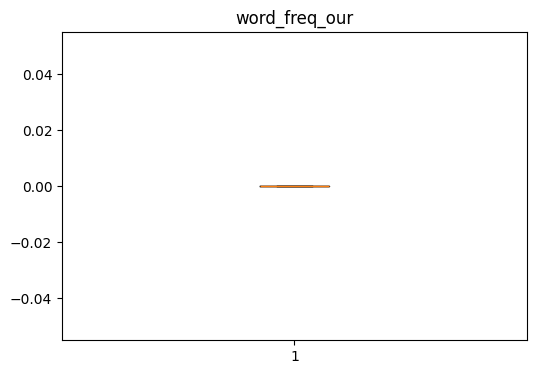

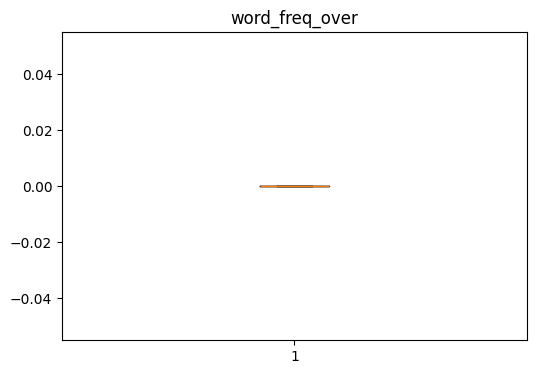

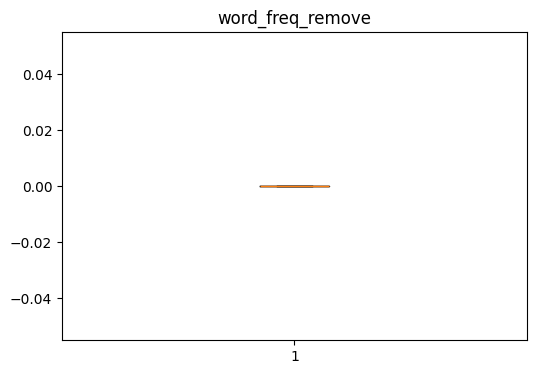

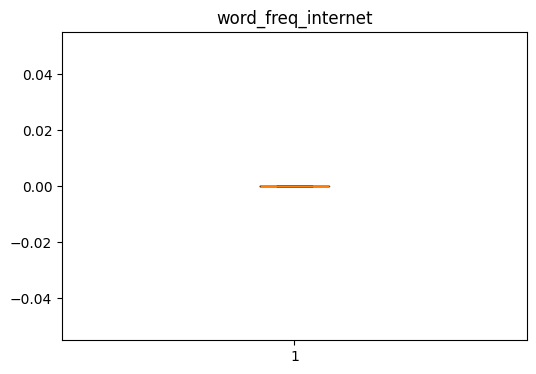

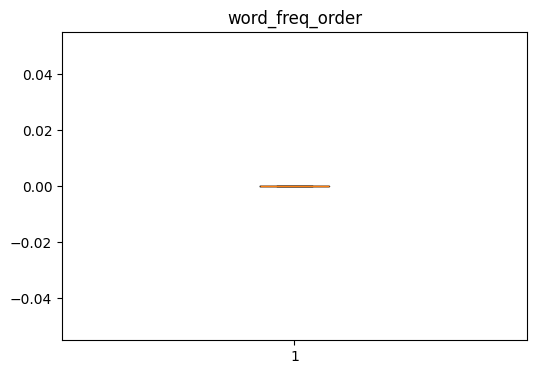

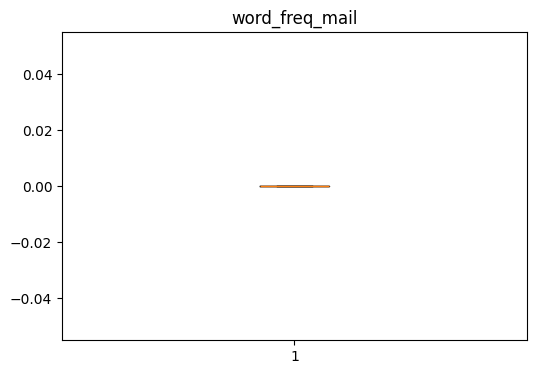

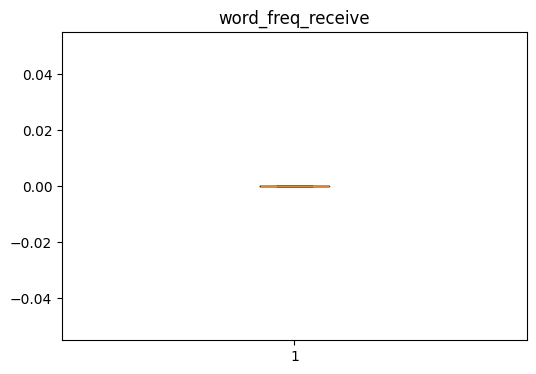

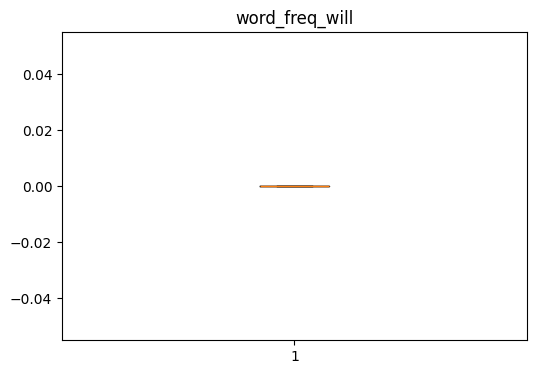

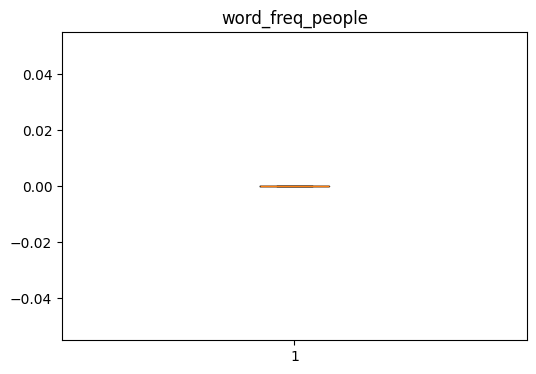

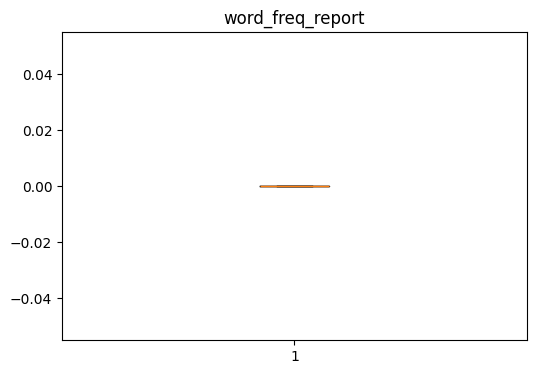

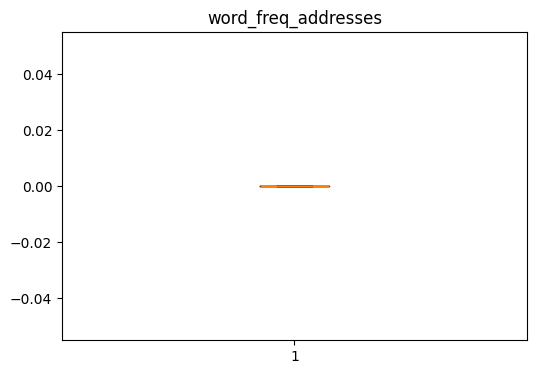

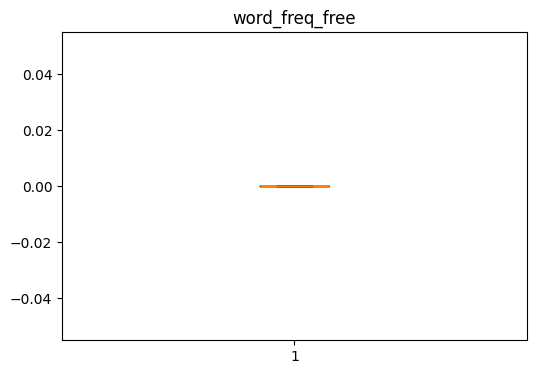

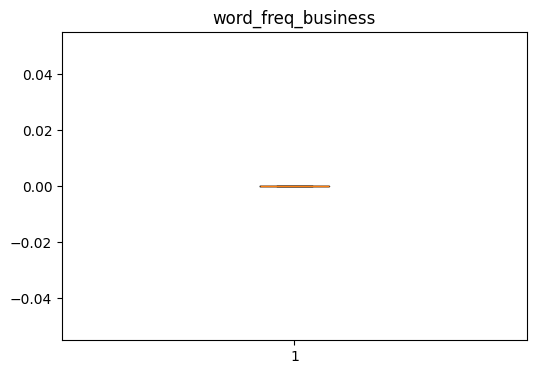

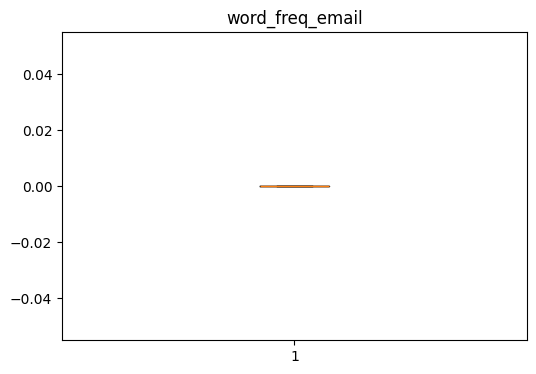

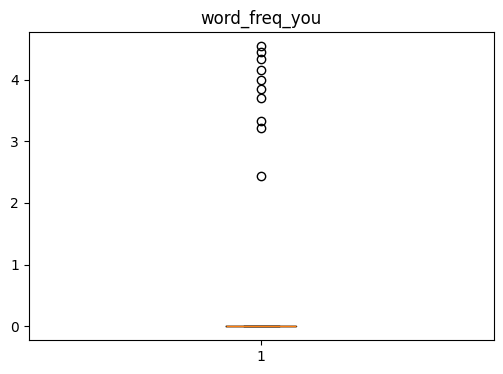

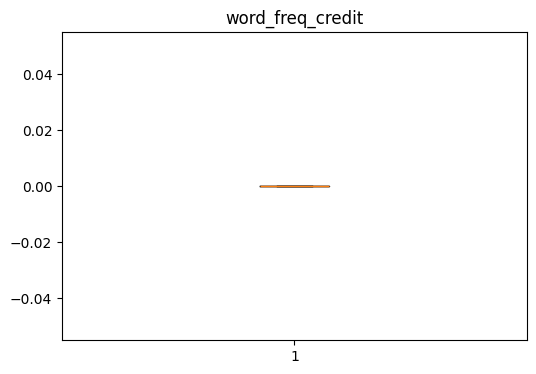

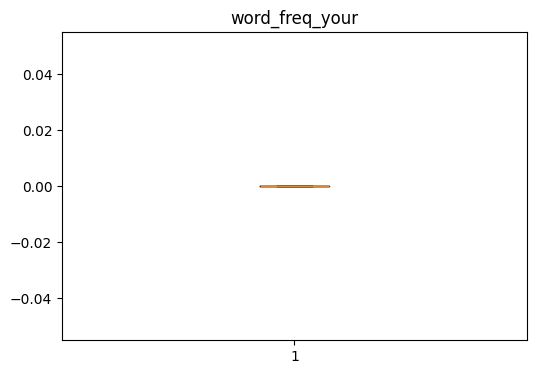

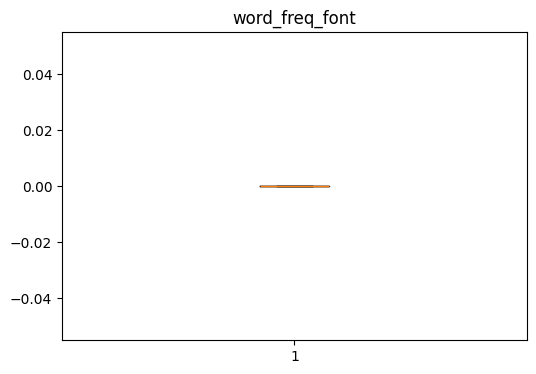

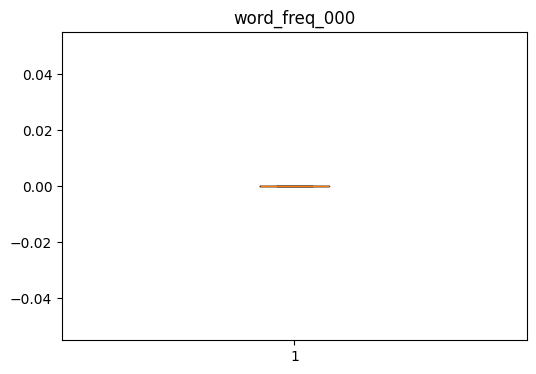

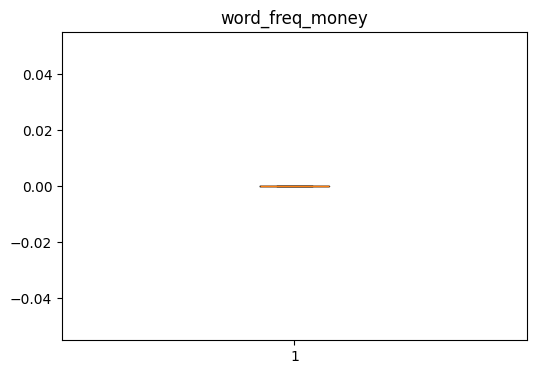

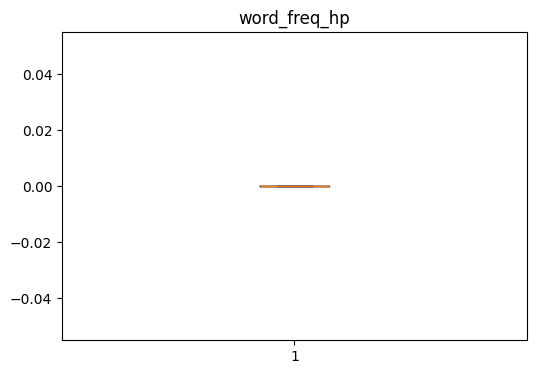

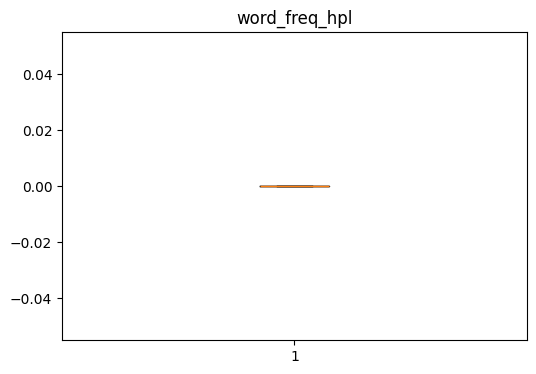

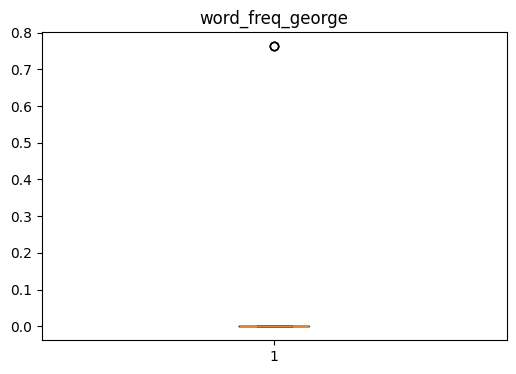

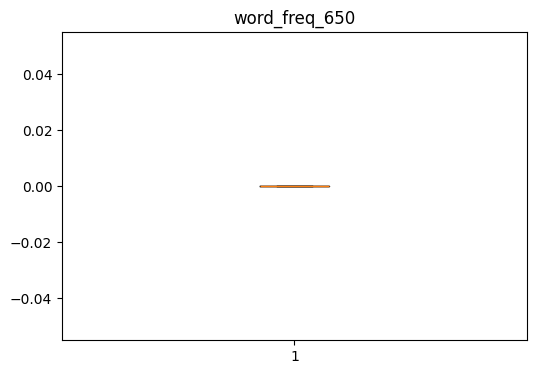

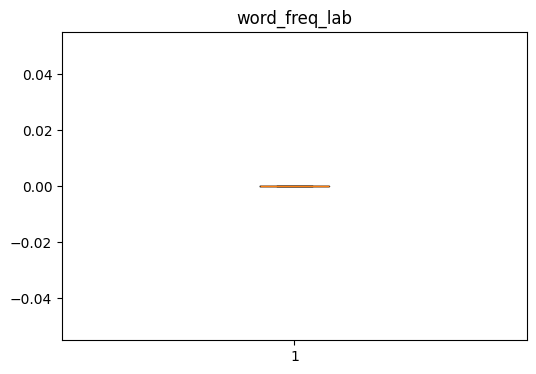

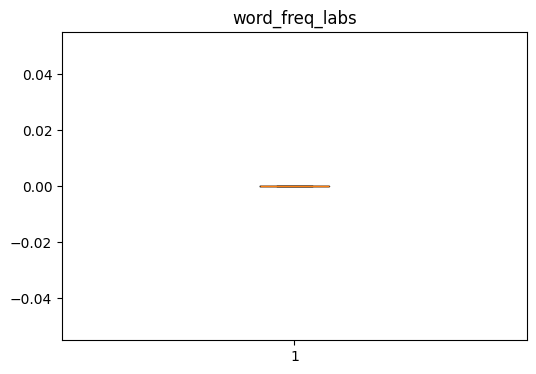

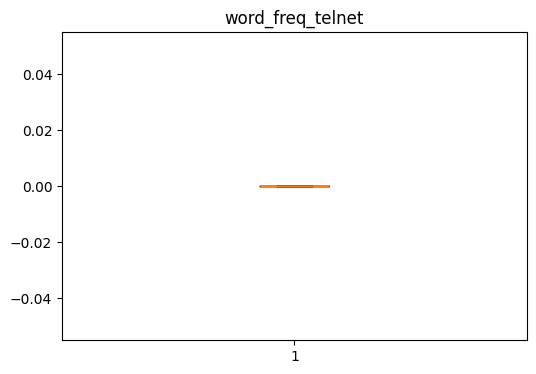

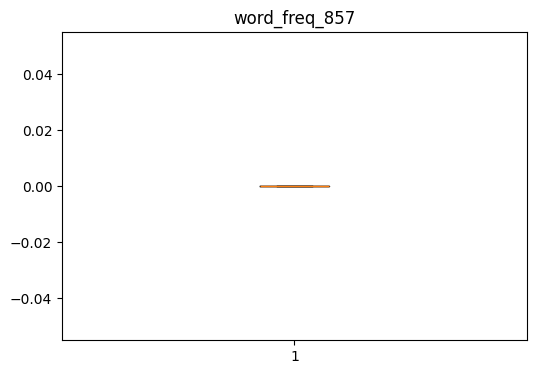

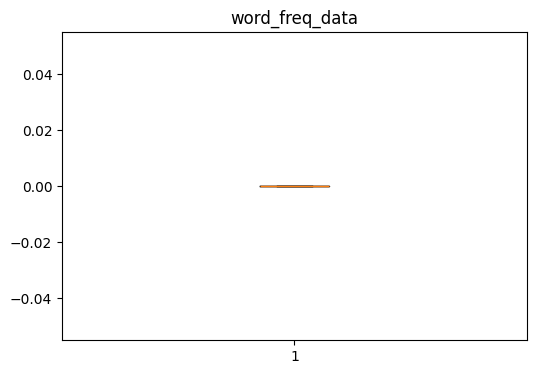

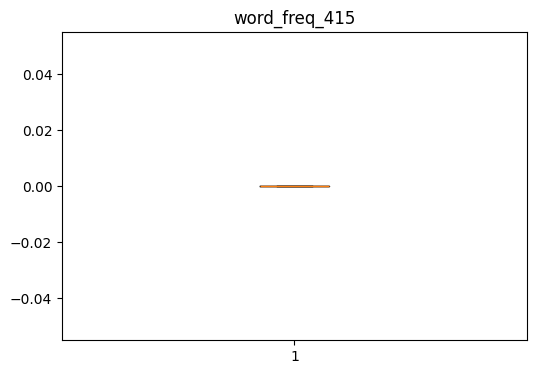

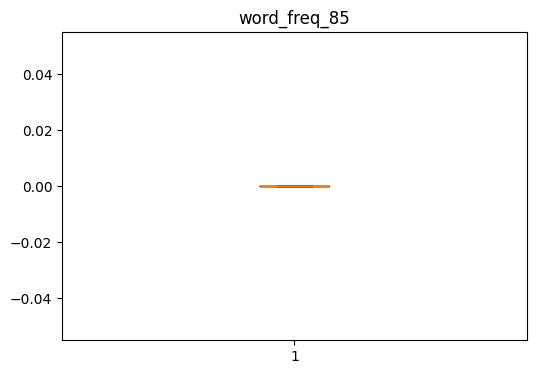

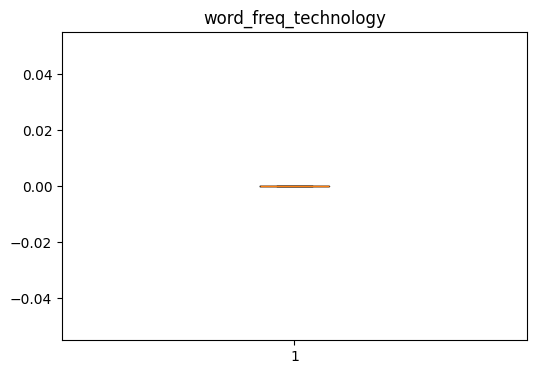

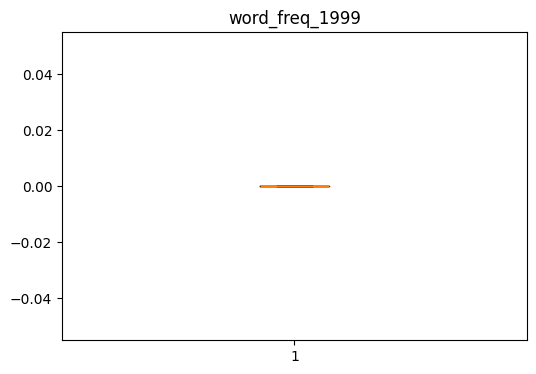

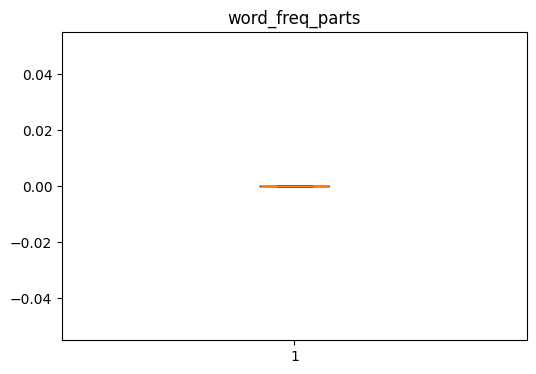

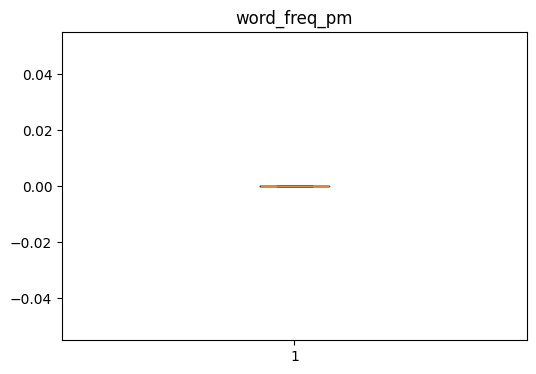

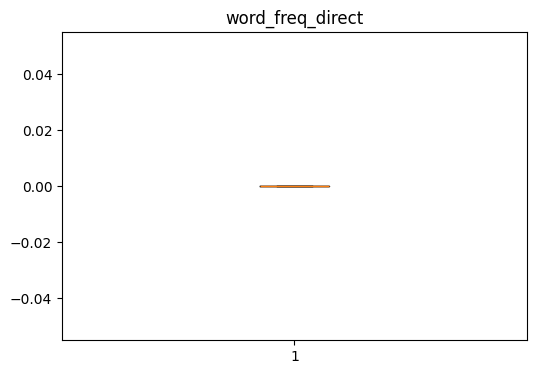

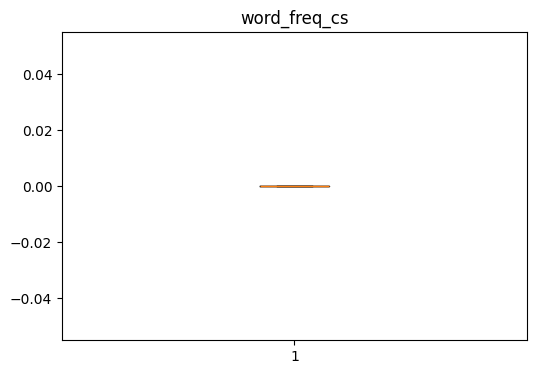

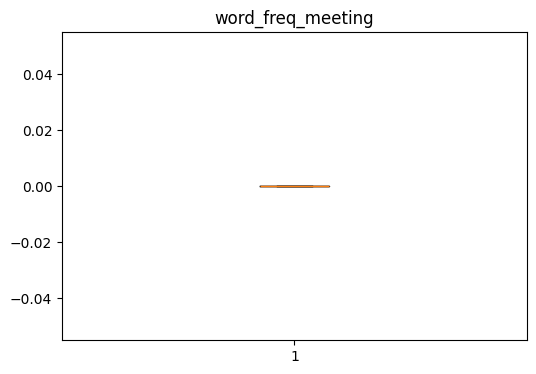

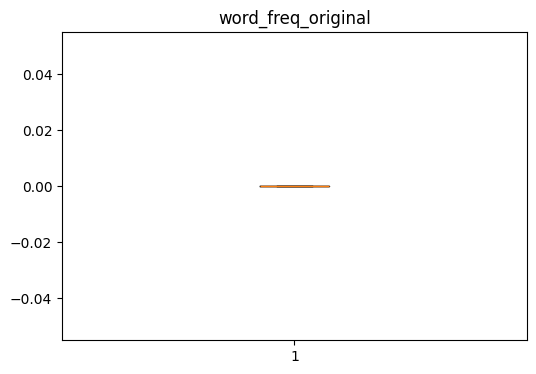

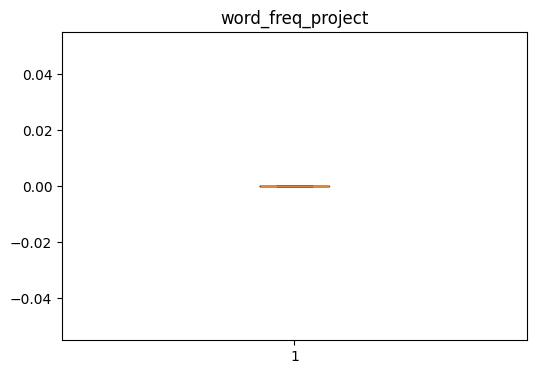

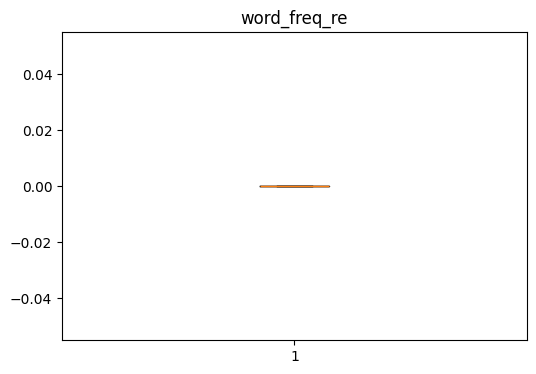

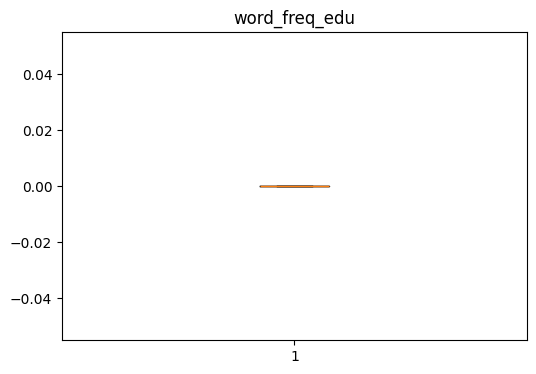

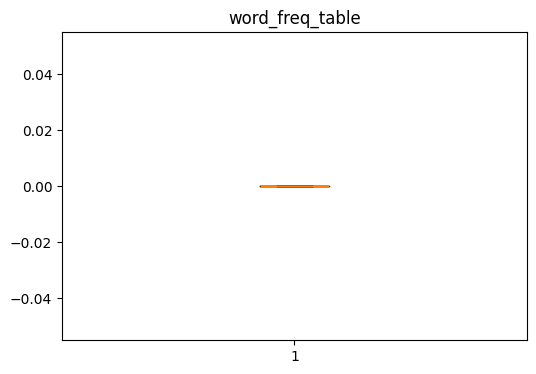

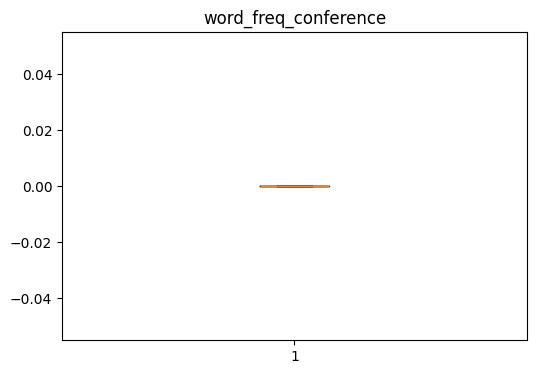

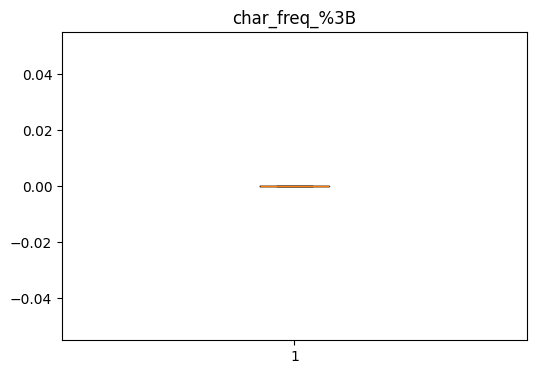

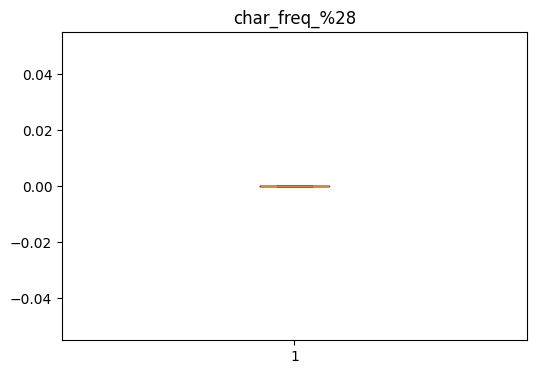

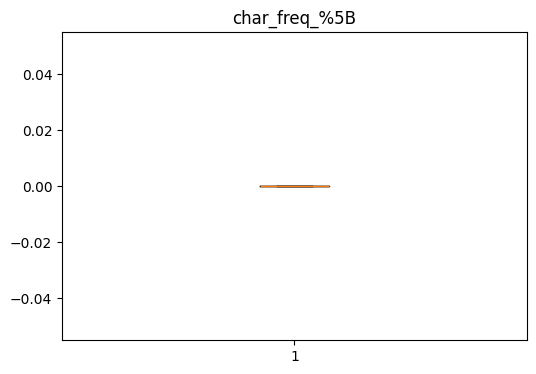

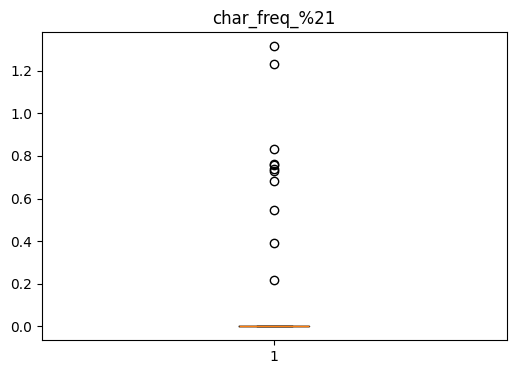

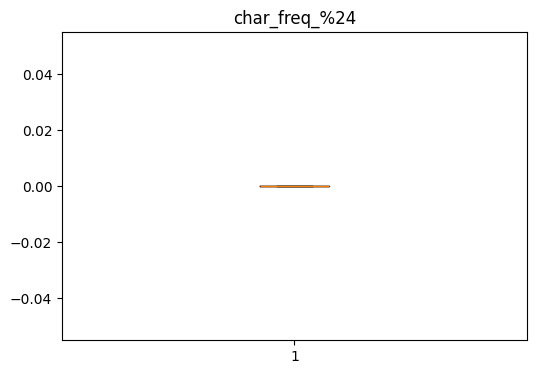

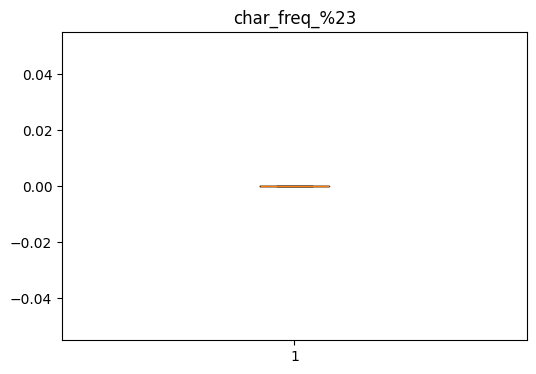

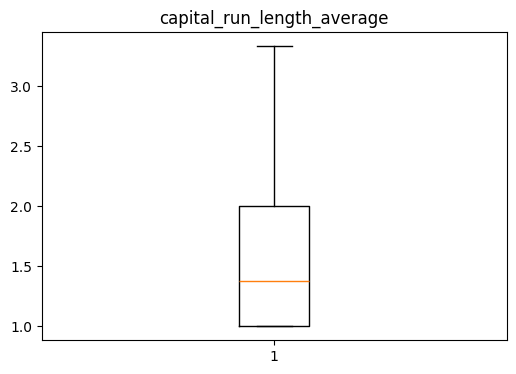

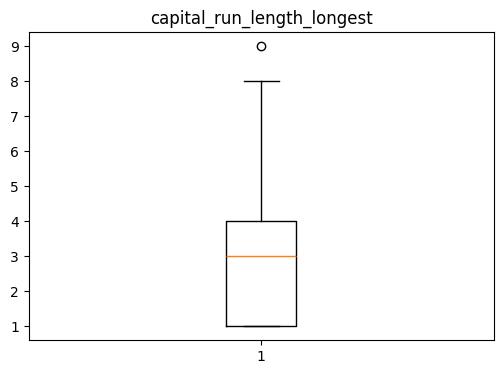

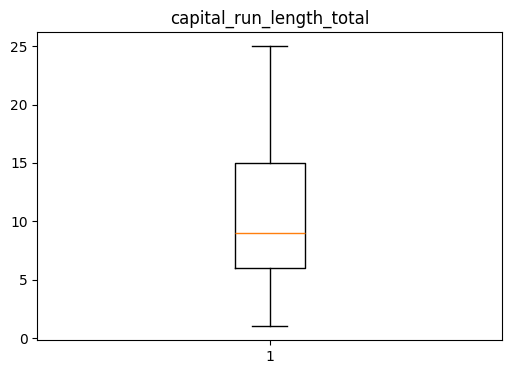

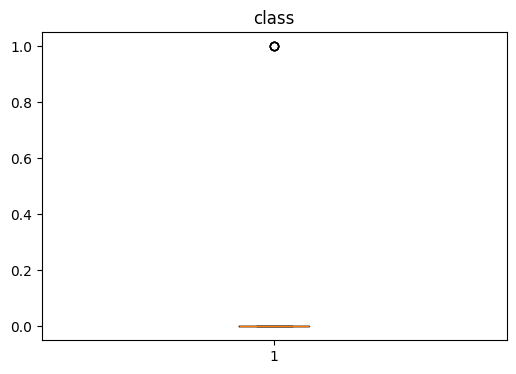

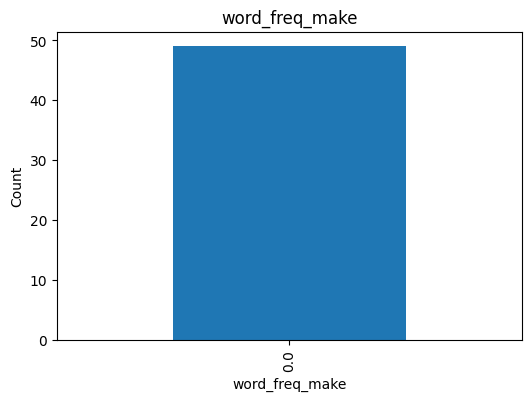

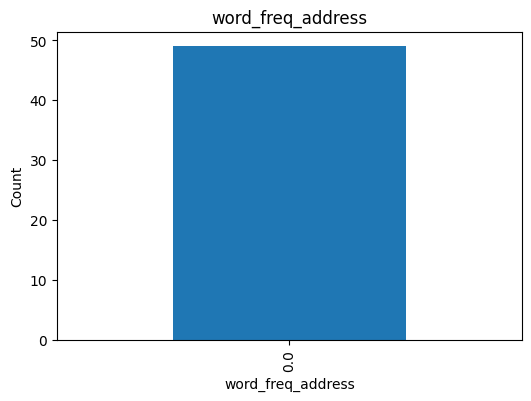

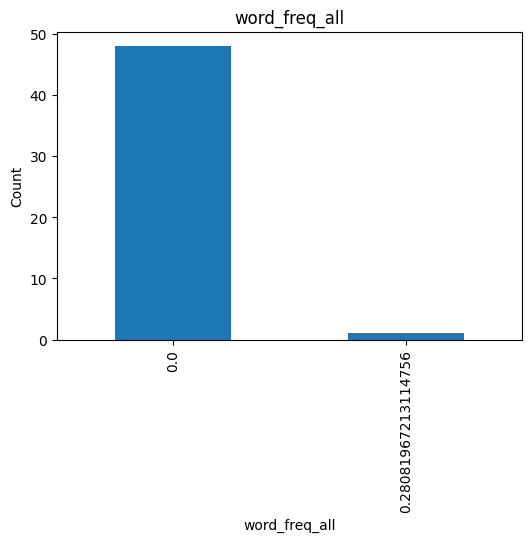

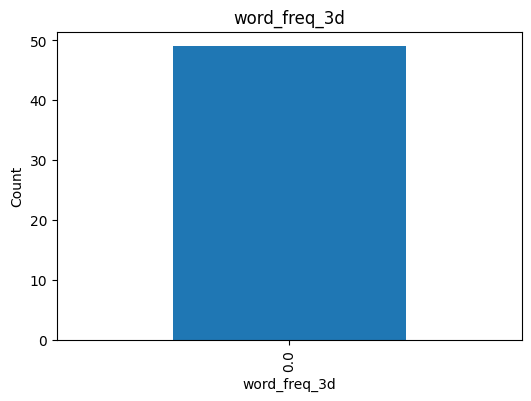

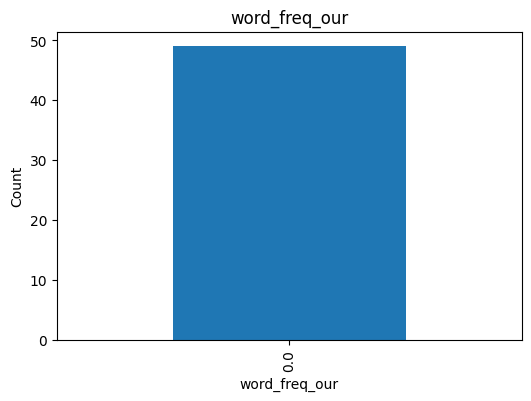

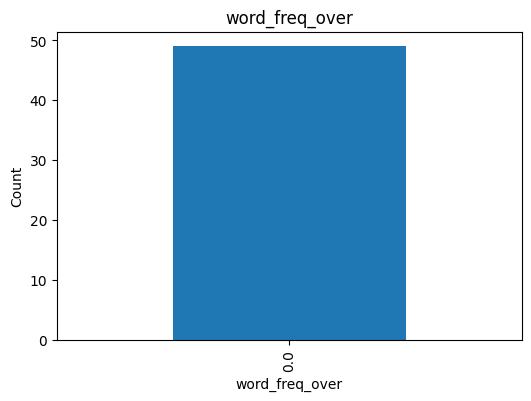

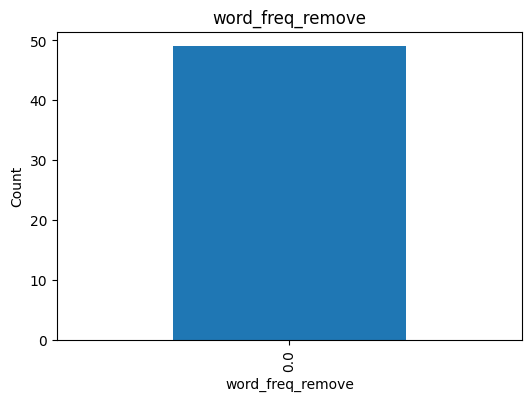

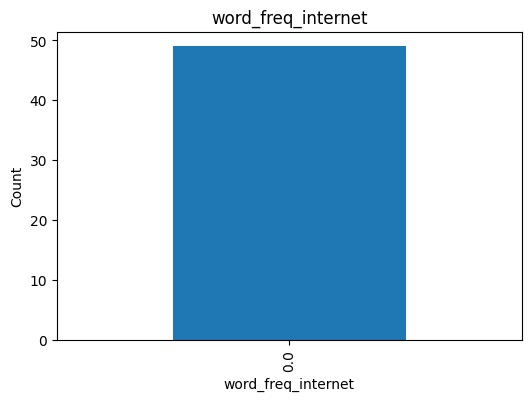

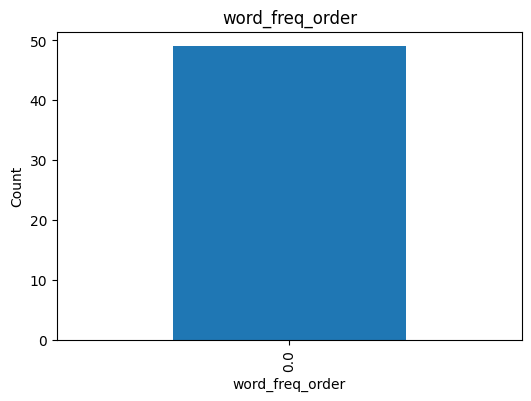

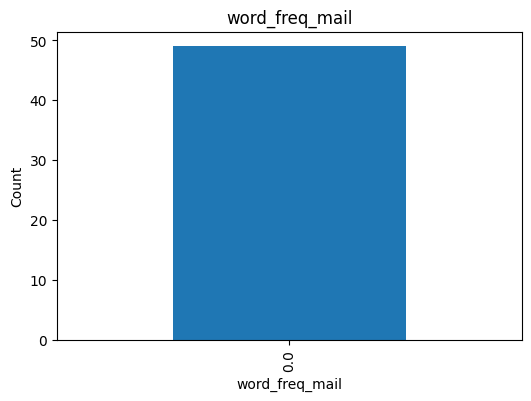

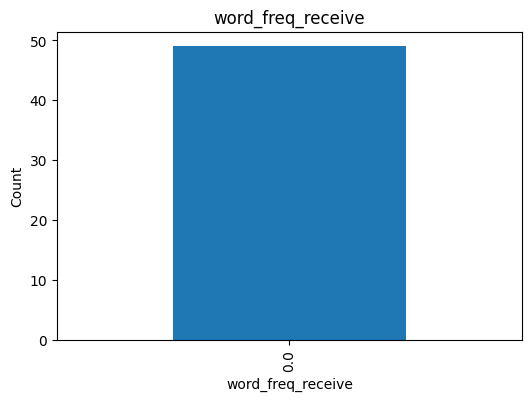

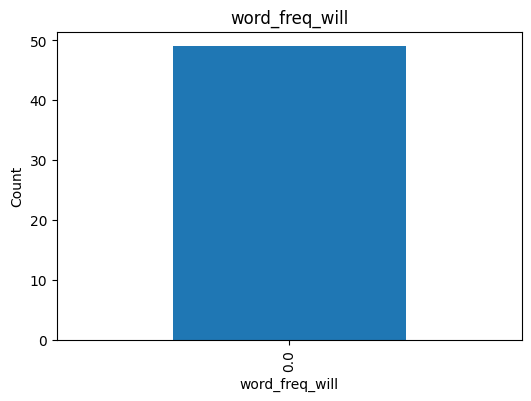

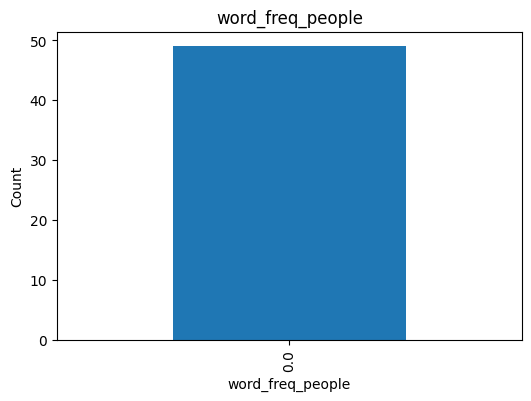

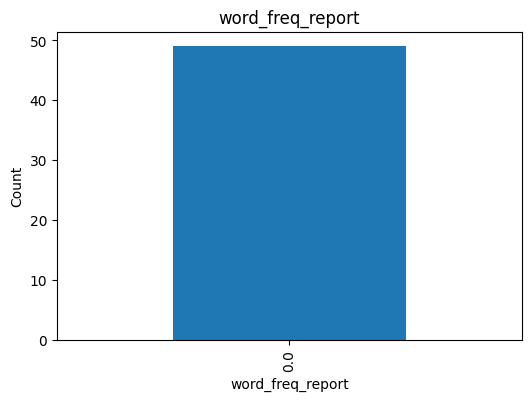

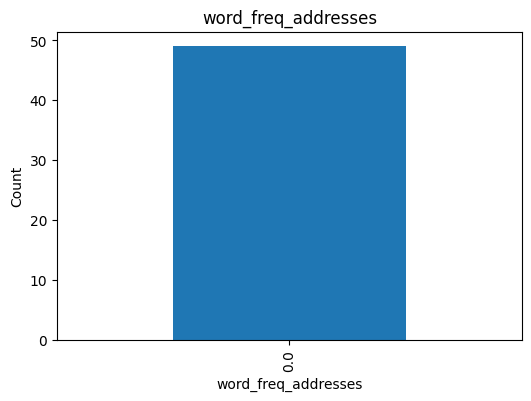

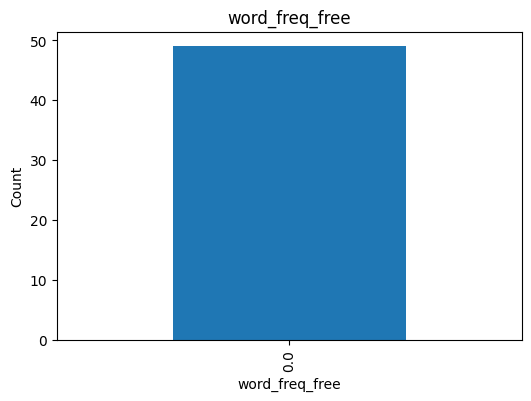

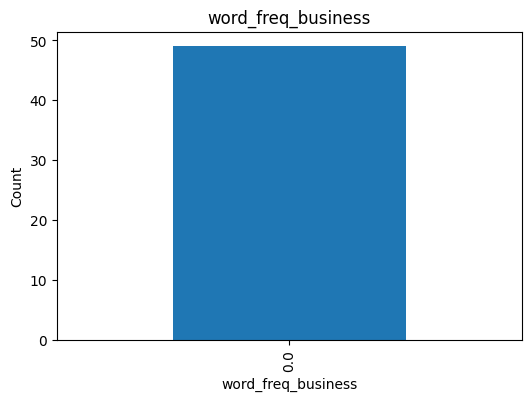

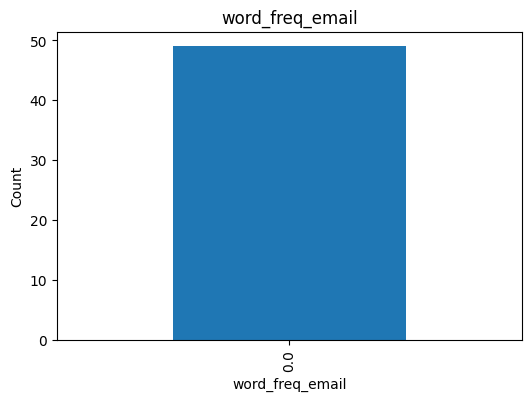

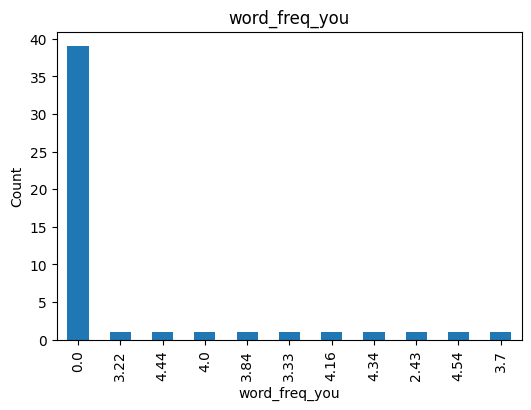

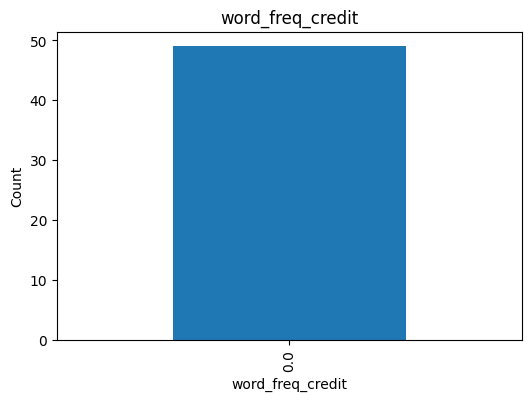

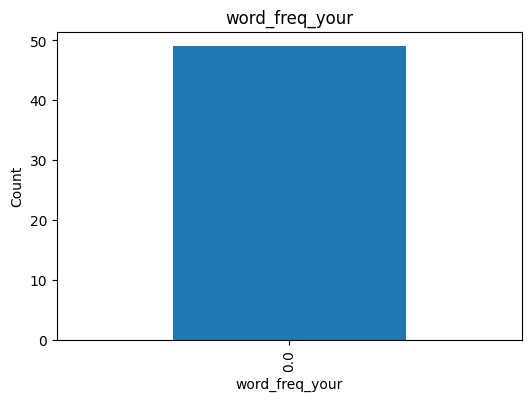

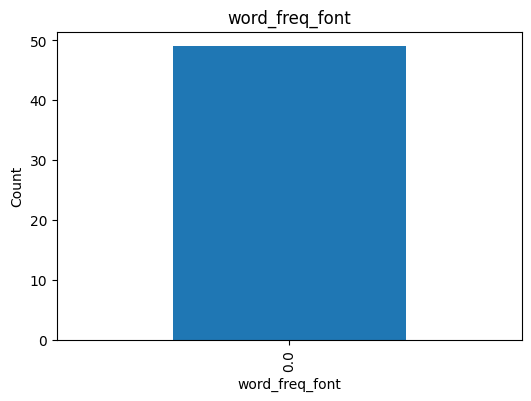

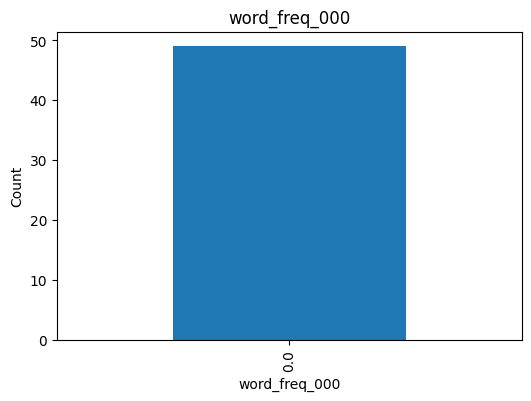

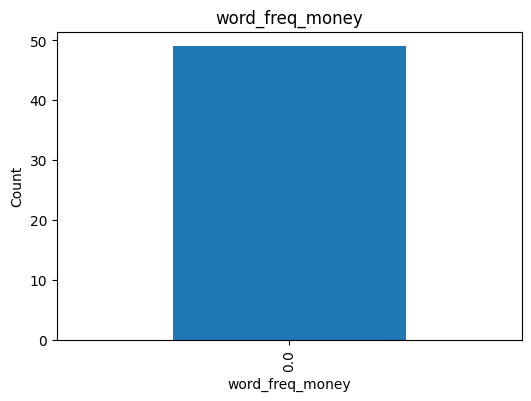

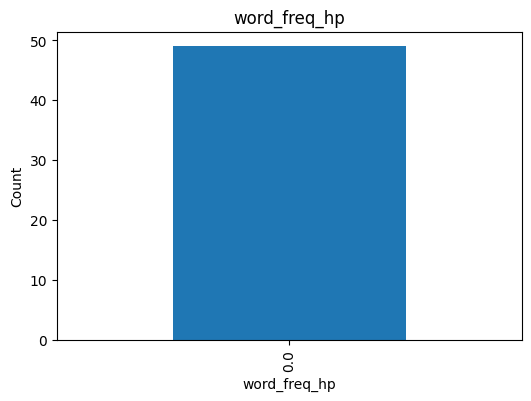

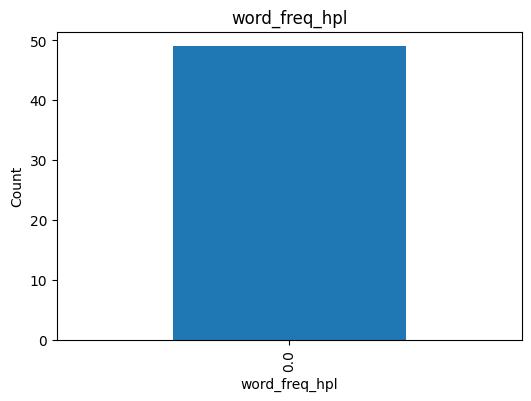

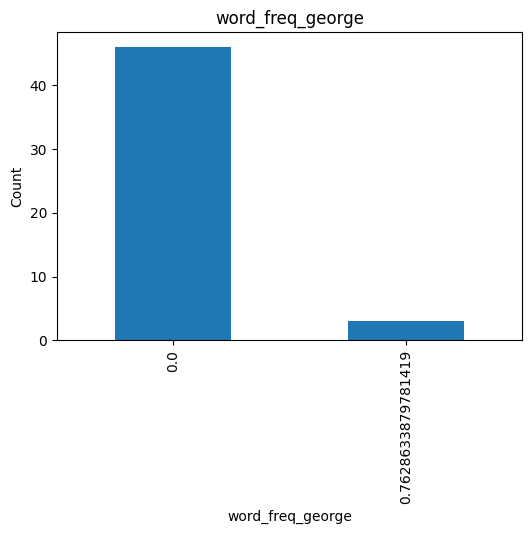

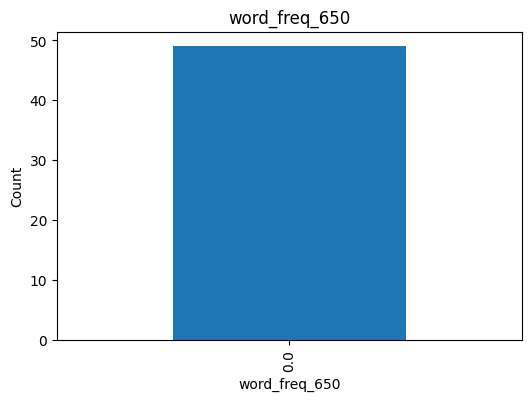

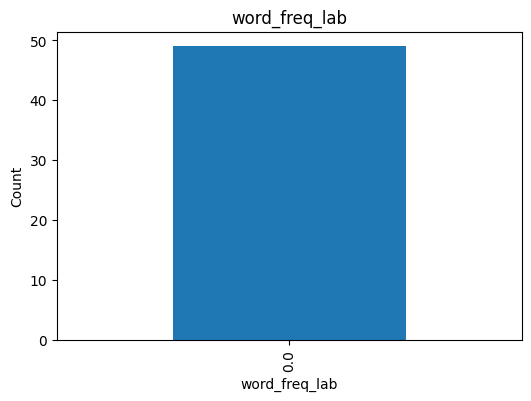

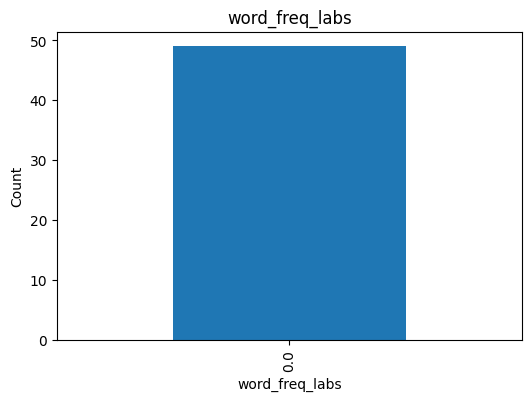

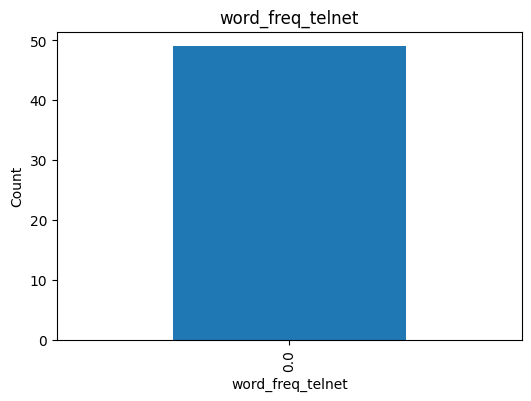

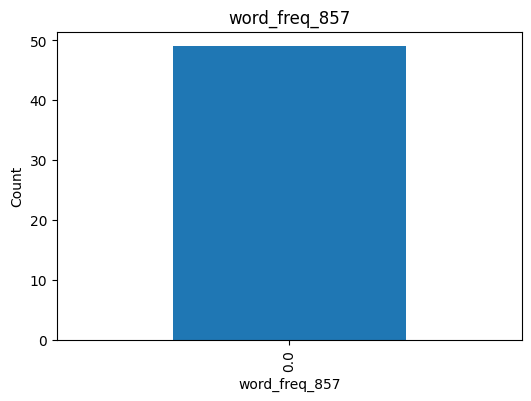

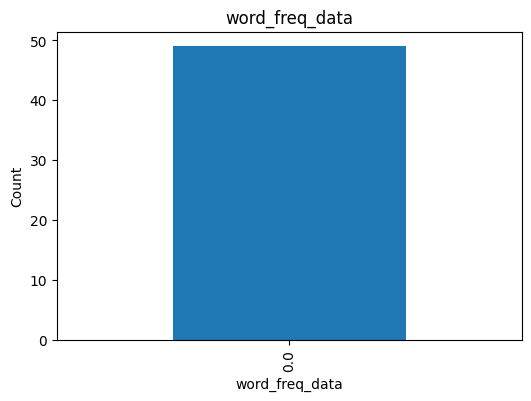

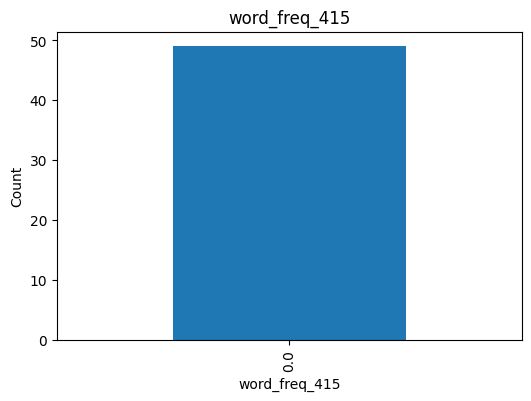

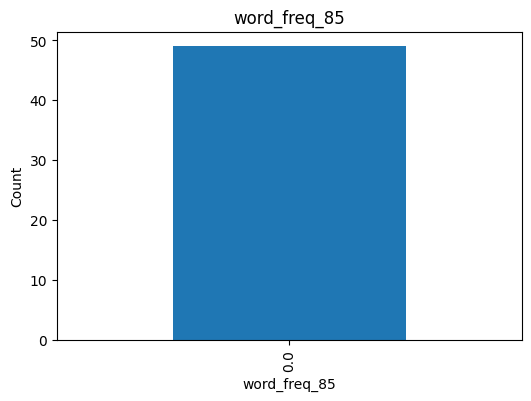

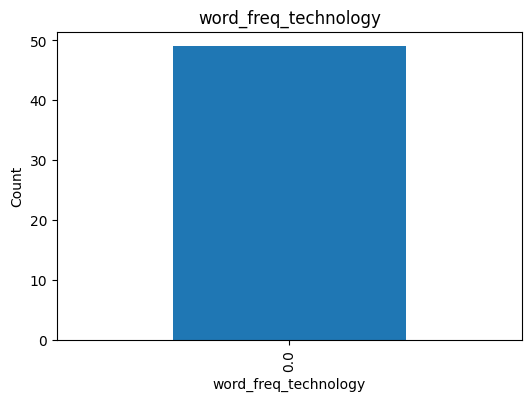

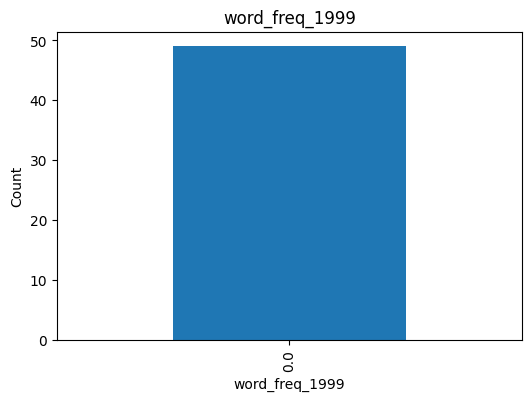

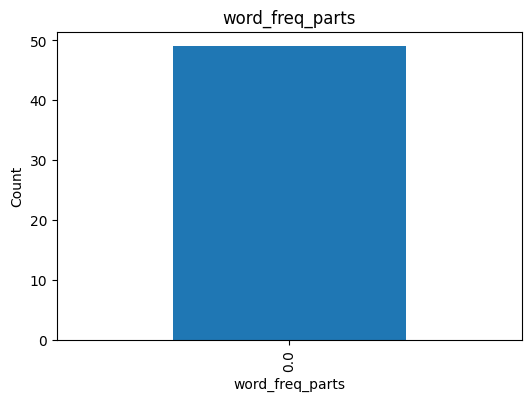

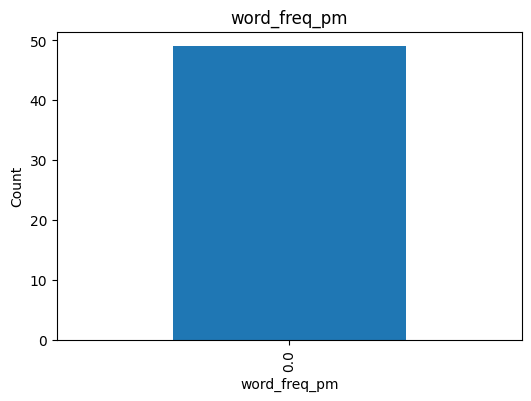

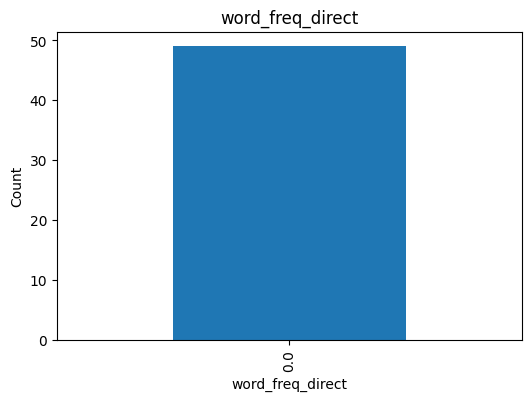

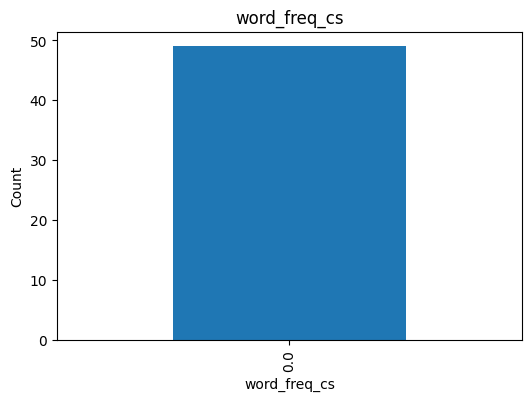

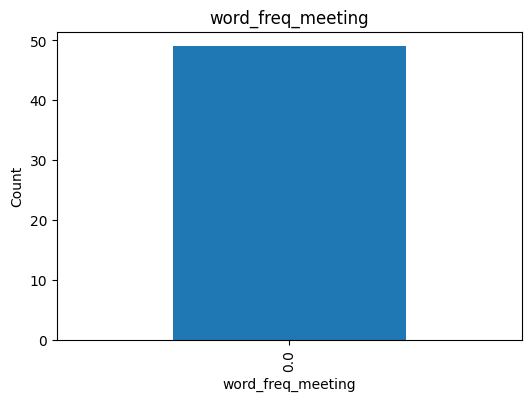

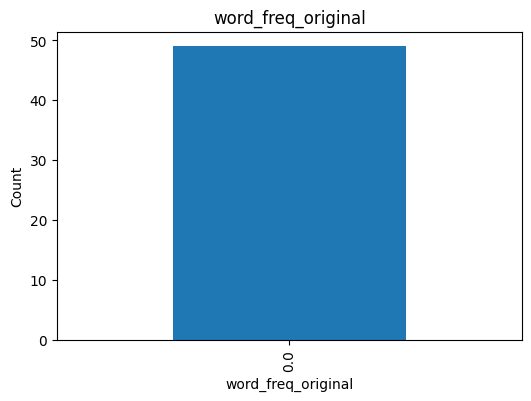

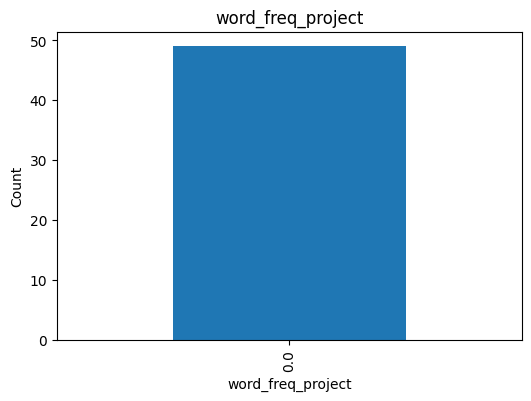

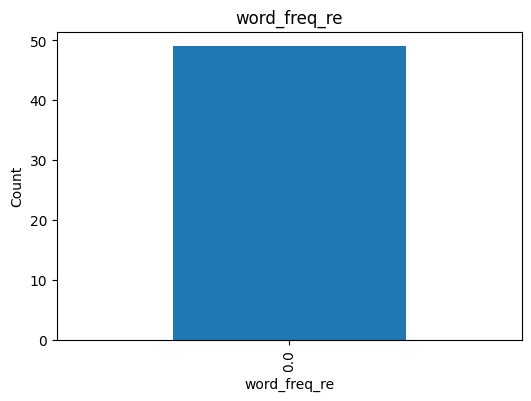

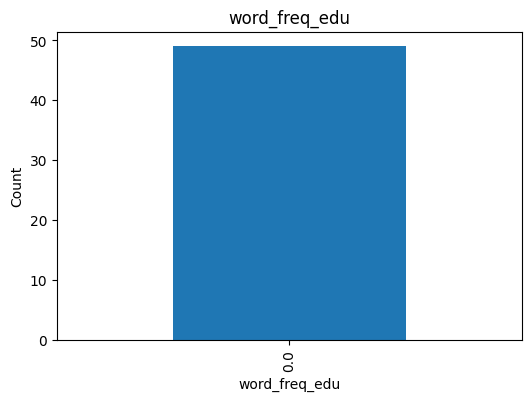

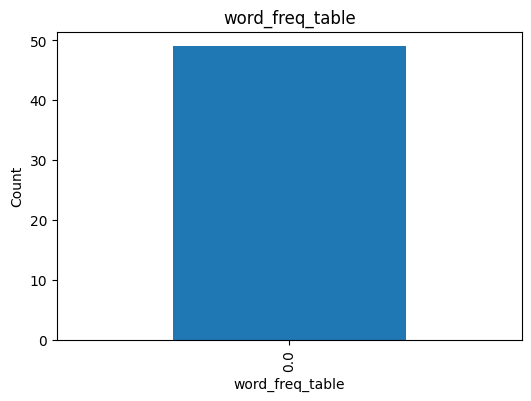

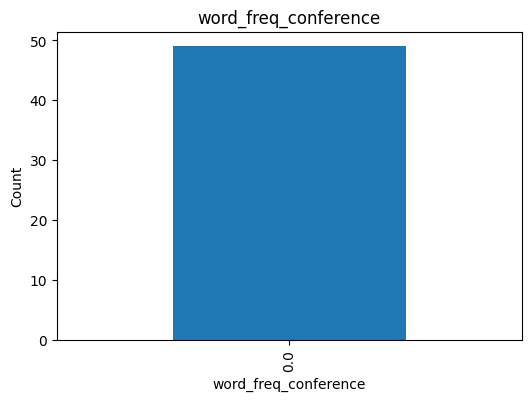

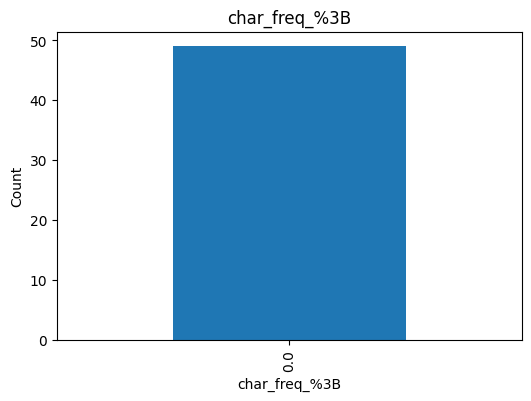

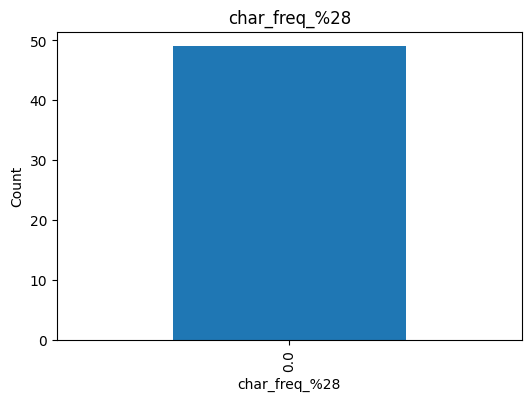

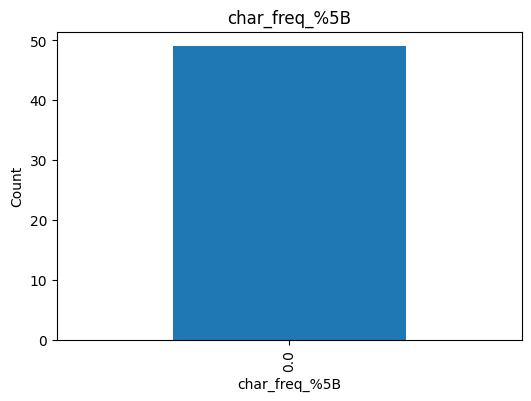

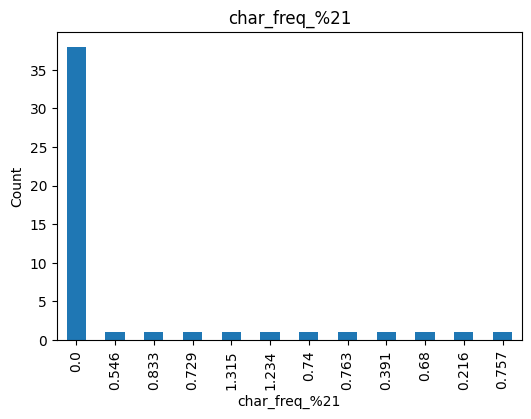

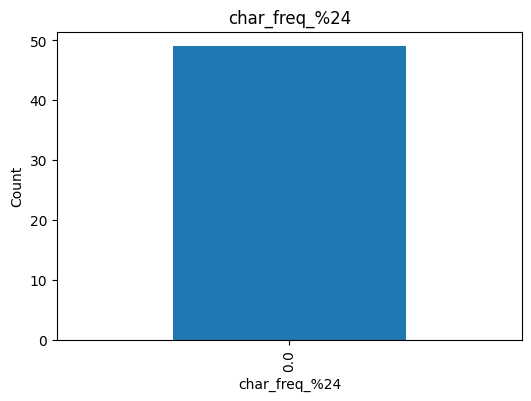

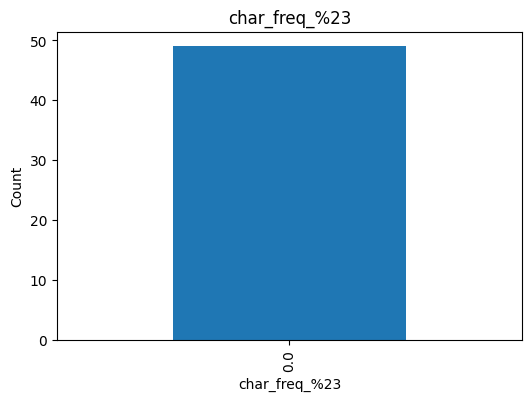

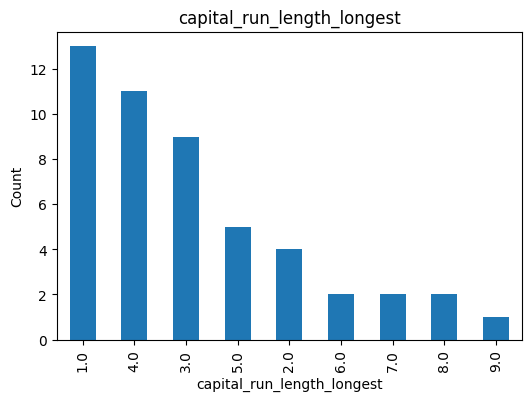

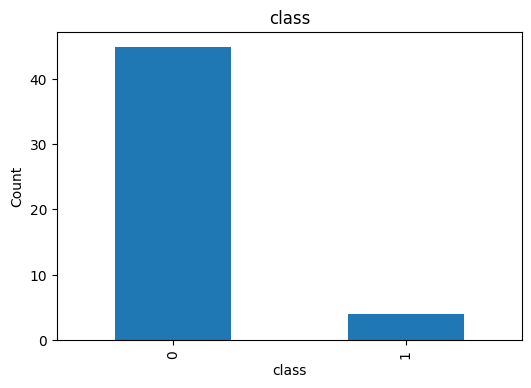

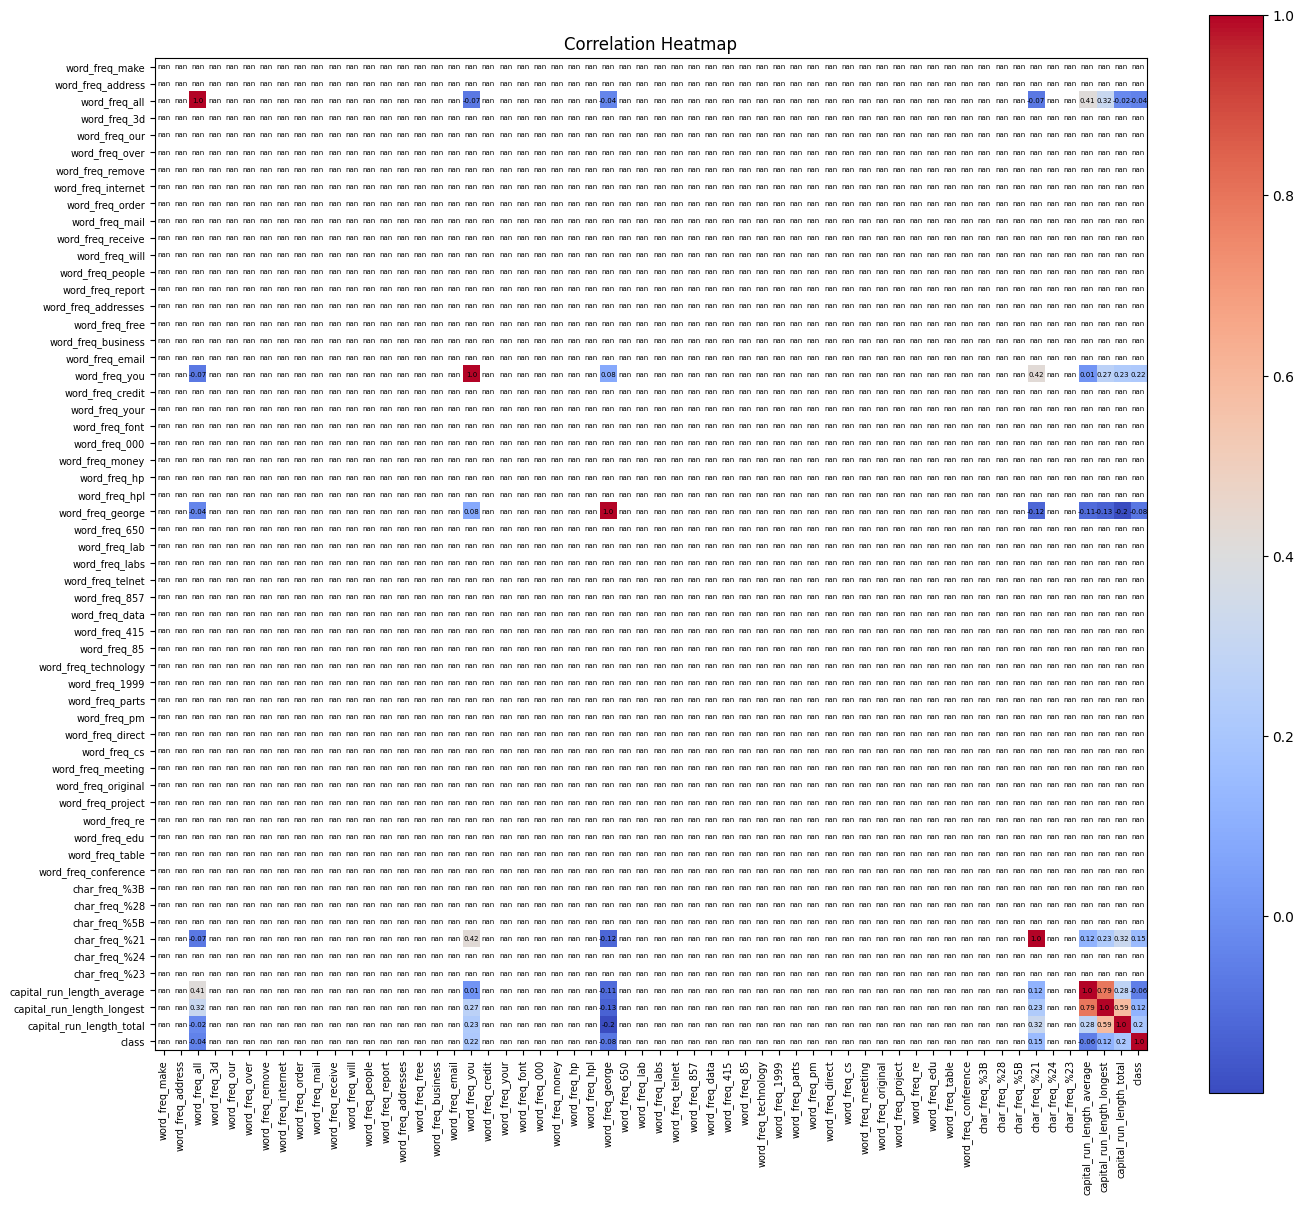


Normalization Completed Successfully
    word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0              0.0                0.0            0.0           0.0   
1              0.0                0.0            0.0           0.0   
2              0.0                0.0            0.0           0.0   
3              0.0                0.0            0.0           0.0   
4              0.0                0.0            0.0           0.0   
5              0.0                0.0            0.0           0.0   
6              0.0                0.0            0.0           0.0   
7              0.0                0.0            0.0           0.0   
8              0.0                0.0            0.0           0.0   
9              0.0                0.0            0.0           0.0   
10             0.0                0.0            0.0           0.0   
11             0.0                0.0            0.0           0.0   
12             0.0                0.0            0.0

In [ ]:
df = pd.read_csv("spambase_unclean.csv")
print(eda(df))

In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (3530, 57)
Testing Features: (883, 57)
Training Labels: (3530,)
Testing Labels: (883,)


In [ ]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)

print("Gaussian Naive Bayes")

print("Accuracy :", accuracy_score(y_test, gnb_pred))
print("Precision:", precision_score(y_test, gnb_pred))
print("Recall   :", recall_score(y_test, gnb_pred))
print("F1 Score :", f1_score(y_test, gnb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gnb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, gnb_pred))

print("\nClassification Report")
print(classification_report(y_test, gnb_pred))

Gaussian Naive Bayes
Accuracy : 0.8131370328425821
Precision: 0.6888888888888889
Recall   : 0.96875
F1 Score : 0.8051948051948052
ROC-AUC  : 0.8393655838041432

Confusion Matrix
[[377 154]
 [ 11 341]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.71      0.82       531
           1       0.69      0.97      0.81       352

    accuracy                           0.81       883
   macro avg       0.83      0.84      0.81       883
weighted avg       0.86      0.81      0.81       883



In [ ]:
mnb = MultinomialNB()

mnb.fit(X_train, y_train)

mnb_pred = mnb.predict(X_test)

print("Multinomial Naive Bayes")

print("Accuracy :", accuracy_score(y_test, mnb_pred))
print("Precision:", precision_score(y_test, mnb_pred))
print("Recall   :", recall_score(y_test, mnb_pred))
print("F1 Score :", f1_score(y_test, mnb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, mnb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, mnb_pred))

print("\nClassification Report")
print(classification_report(y_test, mnb_pred))

Multinomial Naive Bayes
Accuracy : 0.7916194790486977
Precision: 0.7545454545454545
Recall   : 0.7073863636363636
F1 Score : 0.7302052785923754
ROC-AUC  : 0.7774219953775038

Confusion Matrix
[[450  81]
 [103 249]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       531
           1       0.75      0.71      0.73       352

    accuracy                           0.79       883
   macro avg       0.78      0.78      0.78       883
weighted avg       0.79      0.79      0.79       883



In [ ]:
bnb = BernoulliNB()

bnb.fit(X_train, y_train)

bnb_pred = bnb.predict(X_test)

print("Bernoulli Naive Bayes")

print("Accuracy :", accuracy_score(y_test, bnb_pred))
print("Precision:", precision_score(y_test, bnb_pred))
print("Recall   :", recall_score(y_test, bnb_pred))
print("F1 Score :", f1_score(y_test, bnb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, bnb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, bnb_pred))

print("\nClassification Report")
print(classification_report(y_test, bnb_pred))

Bernoulli Naive Bayes
Accuracy : 0.8731596828992072
Precision: 0.875
Recall   : 0.7954545454545454
F1 Score : 0.8333333333333334
ROC-AUC  : 0.8600624892997774

Confusion Matrix
[[491  40]
 [ 72 280]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       531
           1       0.88      0.80      0.83       352

    accuracy                           0.87       883
   macro avg       0.87      0.86      0.87       883
weighted avg       0.87      0.87      0.87       883



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("K-Nearest Neighbors")

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))
print("ROC-AUC  :", roc_auc_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

K-Nearest Neighbors
Accuracy : 0.7802944507361268
Precision: 0.7408536585365854
Recall   : 0.6903409090909091
F1 Score : 0.7147058823529412
ROC-AUC  : 0.765132789762027

Confusion Matrix
[[446  85]
 [109 243]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.74      0.69      0.71       352

    accuracy                           0.78       883
   macro avg       0.77      0.77      0.77       883
weighted avg       0.78      0.78      0.78       883



In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
best_knn.fit(X_train, y_train)
best_pred = best_knn.predict(X_test)

print("Tuned KNN Performance")

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))
print("ROC-AUC  :", roc_auc_score(y_test, best_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report")
print(classification_report(y_test, best_pred))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Cross Validation Accuracy: 0.845042492917847
Tuned KNN Performance
Accuracy : 0.8380520951302378
Precision: 0.8215384615384616
Recall   : 0.7585227272727273
F1 Score : 0.7887740029542097
ROC-AUC  : 0.8246474276664955

Confusion Matrix
[[473  58]
 [ 85 267]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       531
           1       0.82      0.76      0.79       352

    accuracy                           0.84       883
   macro avg       0.83      0.82      0.83       883
weighted avg       0.84      0.84      0.84       883



In [ ]:
param_dist = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}
random = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random.fit(X_train, y_train)

print("Best Parameters:", random.best_params_)
print("Best Cross Validation Accuracy:", random.best_score_)

best_random_knn = random.best_estimator_

best_random_knn.fit(X_train, y_train)

random_pred = best_random_knn.predict(X_test)


print("RandomizedSearchCV KNN")

print("Accuracy :", accuracy_score(y_test, random_pred))
print("Precision:", precision_score(y_test, random_pred))
print("Recall   :", recall_score(y_test, random_pred))
print("F1 Score :", f1_score(y_test, random_pred))
print("ROC-AUC  :", roc_auc_score(y_test, random_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, random_pred))

print("\nClassification Report")
print(classification_report(y_test, random_pred))

Best Parameters: {'weights': 'distance', 'n_neighbors': 8, 'metric': 'manhattan'}
Best Cross Validation Accuracy: 0.8453257790368273
RandomizedSearchCV KNN
Accuracy : 0.8425821064552661
Precision: 0.8297213622291022
Recall   : 0.7613636363636364
F1 Score : 0.794074074074074
ROC-AUC  : 0.8288927409690121

Confusion Matrix
[[476  55]
 [ 84 268]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       531
           1       0.83      0.76      0.79       352

    accuracy                           0.84       883
   macro avg       0.84      0.83      0.83       883
weighted avg       0.84      0.84      0.84       883



In [ ]:
knn_kd = KNeighborsClassifier(
    n_neighbors=5,
    algorithm="kd_tree"
)

knn_kd.fit(X_train, y_train)

kd_pred = knn_kd.predict(X_test)

print("KDTree KNN")

print("Accuracy :", accuracy_score(y_test, kd_pred))
print("Precision:", precision_score(y_test, kd_pred))
print("Recall   :", recall_score(y_test, kd_pred))
print("F1 Score :", f1_score(y_test, kd_pred))
print("ROC-AUC  :", roc_auc_score(y_test, kd_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, kd_pred))

print("\nClassification Report")
print(classification_report(y_test, kd_pred))

KDTree KNN
Accuracy : 0.7802944507361268
Precision: 0.7408536585365854
Recall   : 0.6903409090909091
F1 Score : 0.7147058823529412
ROC-AUC  : 0.765132789762027

Confusion Matrix
[[446  85]
 [109 243]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.74      0.69      0.71       352

    accuracy                           0.78       883
   macro avg       0.77      0.77      0.77       883
weighted avg       0.78      0.78      0.78       883



In [ ]:
knn_ball = KNeighborsClassifier(
    n_neighbors=5,
    algorithm="ball_tree"
)

knn_ball.fit(X_train, y_train)

ball_pred = knn_ball.predict(X_test)

print("BallTree KNN")

print("Accuracy :", accuracy_score(y_test, ball_pred))
print("Precision:", precision_score(y_test, ball_pred))
print("Recall   :", recall_score(y_test, ball_pred))
print("F1 Score :", f1_score(y_test, ball_pred))
print("ROC-AUC  :", roc_auc_score(y_test, ball_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, ball_pred))

print("\nClassification Report")
print(classification_report(y_test, ball_pred))

BallTree KNN
Accuracy : 0.7802944507361268
Precision: 0.7408536585365854
Recall   : 0.6903409090909091
F1 Score : 0.7147058823529412
ROC-AUC  : 0.765132789762027

Confusion Matrix
[[446  85]
 [109 243]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.74      0.69      0.71       352

    accuracy                           0.78       883
   macro avg       0.77      0.77      0.77       883
weighted avg       0.78      0.78      0.78       883



In [ ]:
print("KDTree Accuracy :", accuracy_score(y_test, kd_pred))
print("BallTree Accuracy:", accuracy_score(y_test, ball_pred))

KDTree Accuracy : 0.7802944507361268
BallTree Accuracy: 0.7802944507361268


In [ ]:
gnb = GaussianNB()

gnb_scores = cross_val_score(
    gnb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Gaussian Naive Bayes")
print("Cross Validation Scores:", gnb_scores)
print("Average Accuracy:", gnb_scores.mean())

Gaussian Naive Bayes
Cross Validation Scores: [0.84937712 0.86409966 0.8380521  0.85714286 0.69727891]
Average Accuracy: 0.821190129505936


In [ ]:
mnb = MultinomialNB()

mnb_scores = cross_val_score(
    mnb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Multinomial Naive Bayes")
print("Cross Validation Scores:", mnb_scores)
print("Average Accuracy:", mnb_scores.mean())

Multinomial Naive Bayes
Cross Validation Scores: [0.78708947 0.79728199 0.8006795  0.80952381 0.68480726]
Average Accuracy: 0.7758764056774087


In [ ]:
bnb = BernoulliNB()

bnb_scores = cross_val_score(
    bnb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Bernoulli Naive Bayes")
print("Cross Validation Scores:", bnb_scores)
print("Average Accuracy:", bnb_scores.mean())

Bernoulli Naive Bayes
Cross Validation Scores: [0.88674972 0.89354473 0.89467724 0.90249433 0.7755102 ]
Average Accuracy: 0.8705952445153222


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("KNN")
print("Cross Validation Scores:", knn_scores)
print("Average Accuracy:", knn_scores.mean())

KNN
Cross Validation Scores: [0.74631937 0.77236693 0.80634202 0.79931973 0.73469388]
Average Accuracy: 0.7718083836025916


In [ ]:
print("\nAverage Cross Validation Accuracy")

print("Gaussian NB    :", gnb_scores.mean())
print("Multinomial NB :", mnb_scores.mean())
print("Bernoulli NB   :", bnb_scores.mean())
print("KNN            :", knn_scores.mean())


Average Cross Validation Accuracy
Gaussian NB    : 0.821190129505936
Multinomial NB : 0.7758764056774087
Bernoulli NB   : 0.8705952445153222
KNN            : 0.7718083836025916


In [ ]:
time_results=[]
start = time.time()
gnb.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
gnb.predict(X_test)
predict_time = time.time() - start

print("Gaussian Naive Bayes")
print("Training Time :", train_time)
print("Prediction Time:", predict_time)
time_results.append({
    "Model": "Gaussian Naive Bayes",
    "Training Time (s)": train_time,
    "Prediction Time (s)": predict_time
})

Gaussian Naive Bayes
Training Time : 0.015959739685058594
Prediction Time: 0.003484964370727539


In [ ]:
start = time.time()
mnb.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
mnb.predict(X_test)
predict_time = time.time() - start

print("Multinomial Naive Bayes")
print("Training Time :", train_time)
print("Prediction Time:", predict_time)
time_results.append({
    "Model": "Multinomial Naive Bayes",
    "Training Time (s)": train_time,
    "Prediction Time (s)": predict_time
})

Multinomial Naive Bayes
Training Time : 0.008372068405151367
Prediction Time: 0.0029506683349609375


In [ ]:
start = time.time()
bnb.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
bnb.predict(X_test)
predict_time = time.time() - start

print("Bernoulli Naive Bayes")
print("Training Time :", train_time)
print("Prediction Time:", predict_time)
time_results.append({
    "Model": "Bernoulli Naive Bayes",
    "Training Time (s)": train_time,
    "Prediction Time (s)": predict_time
})

Bernoulli Naive Bayes
Training Time : 0.01139378547668457
Prediction Time: 0.004172086715698242


In [ ]:
start = time.time()
knn.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
knn.predict(X_test)
predict_time = time.time() - start

print("KNN")
print("Training Time :", train_time)
print("Prediction Time:", predict_time)
time_results.append({
    "Model": "KNN",
    "Training Time (s)": train_time,
    "Prediction Time (s)": predict_time
})

KNN
Training Time : 0.006868124008178711
Prediction Time: 0.03470468521118164


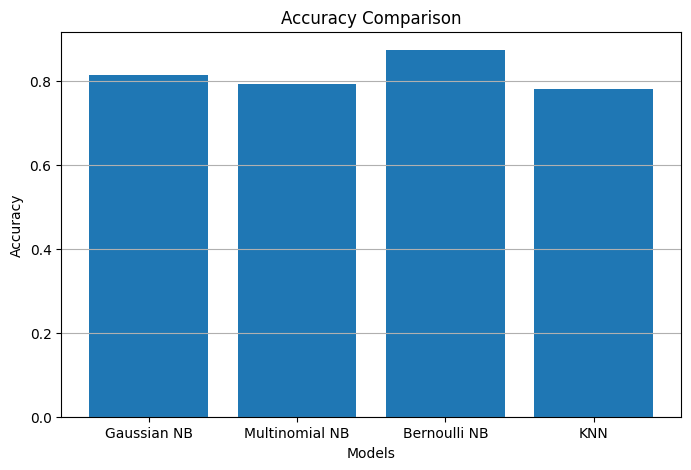

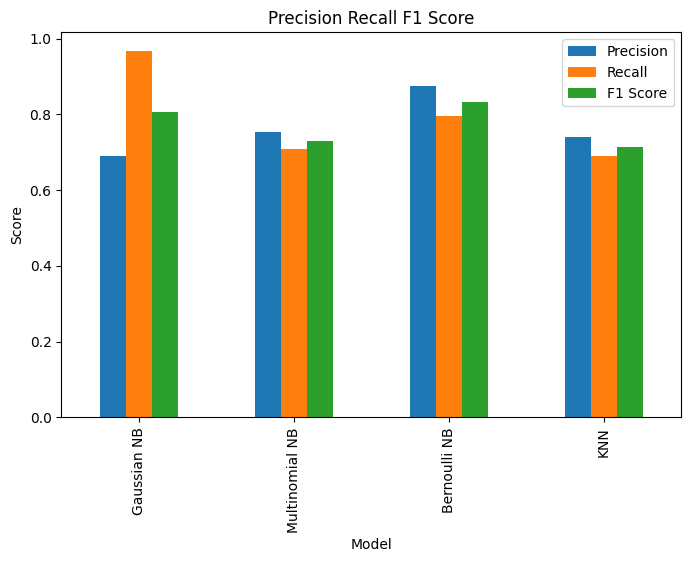

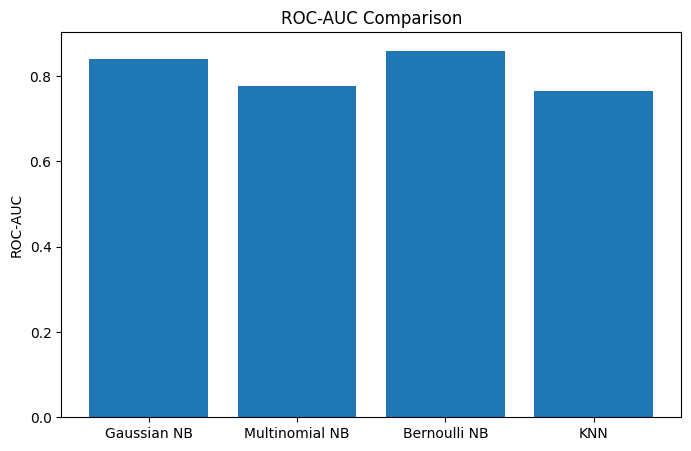

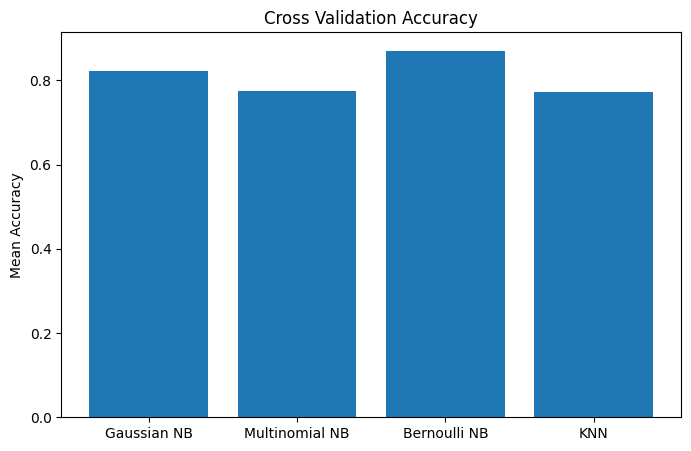

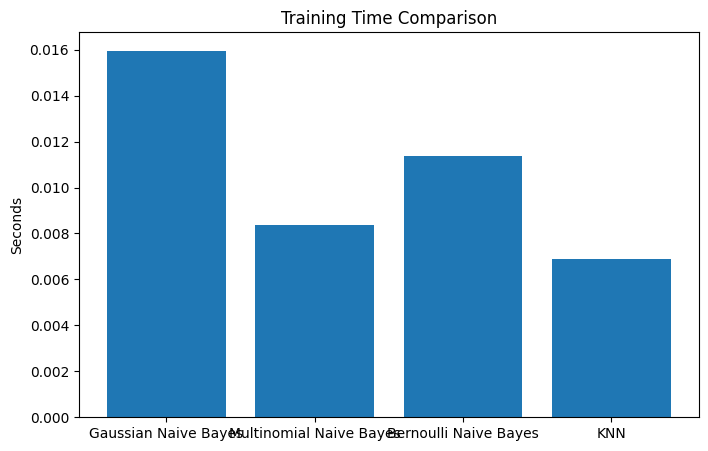

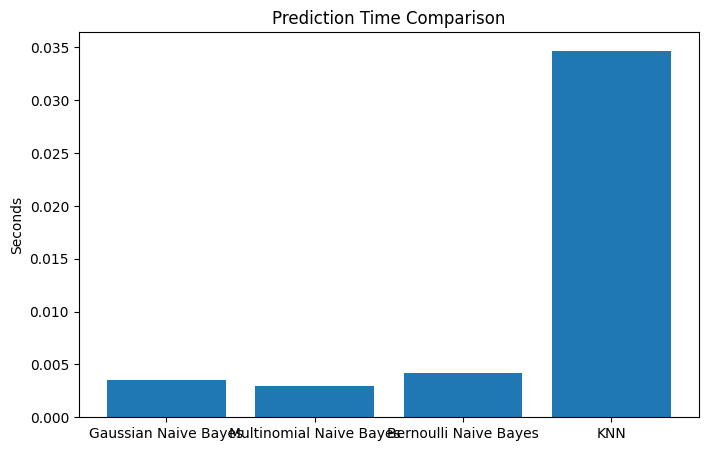

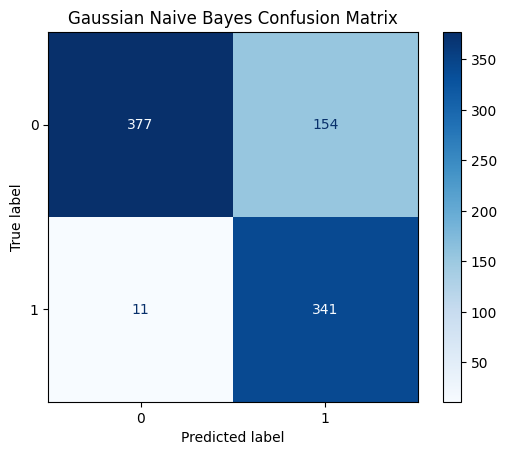

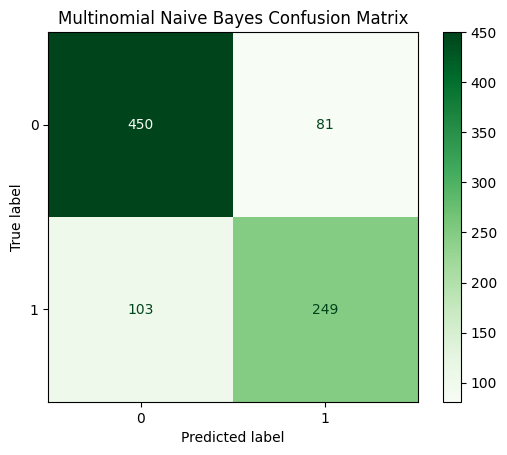

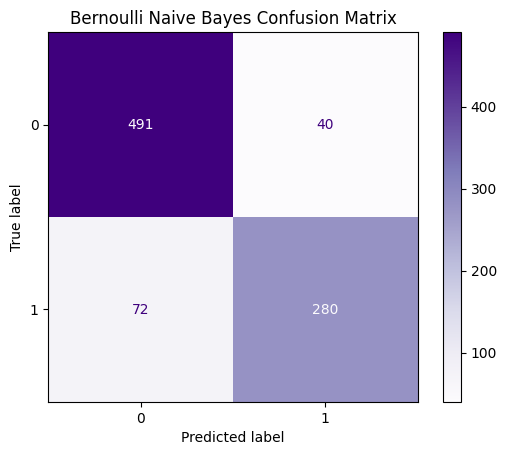

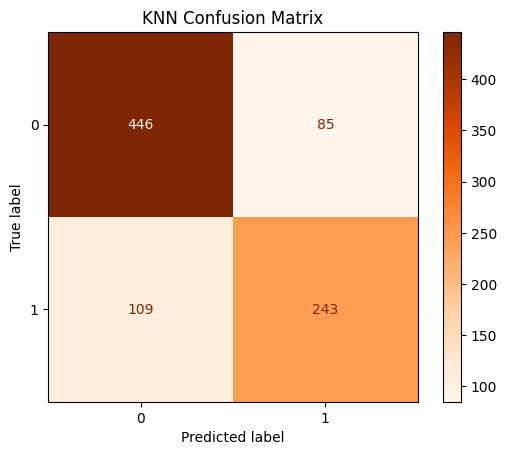

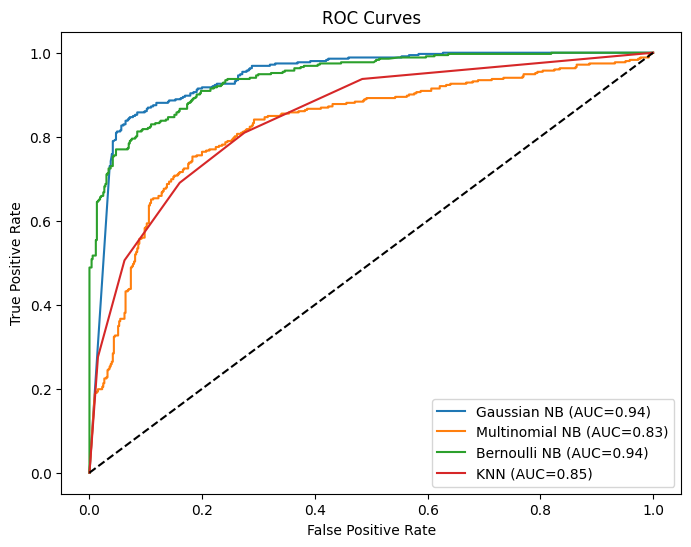

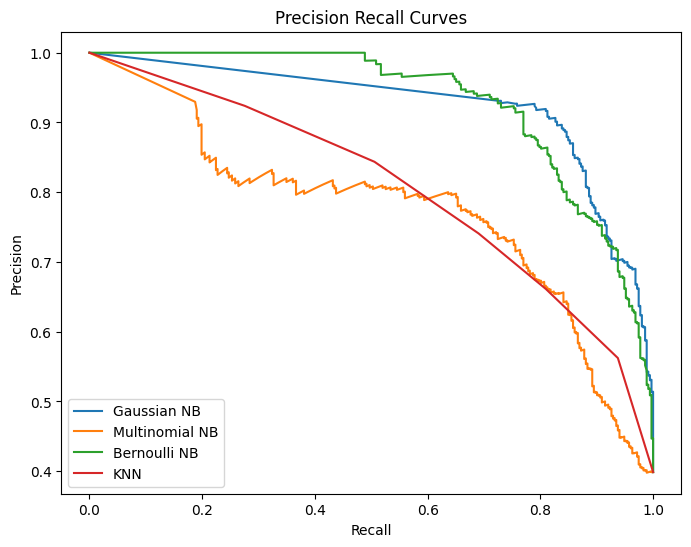

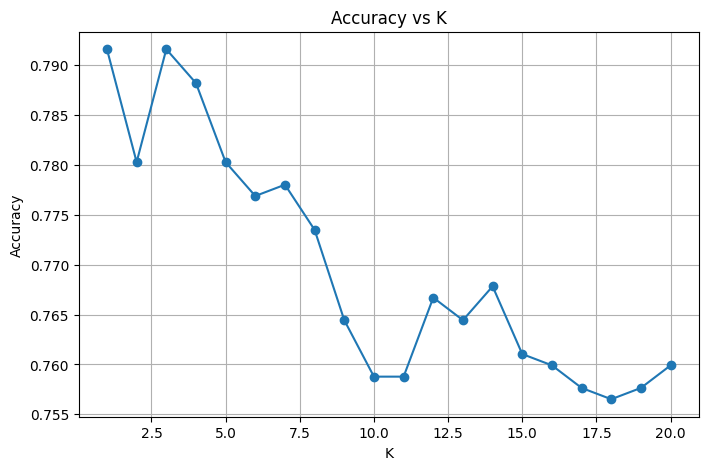

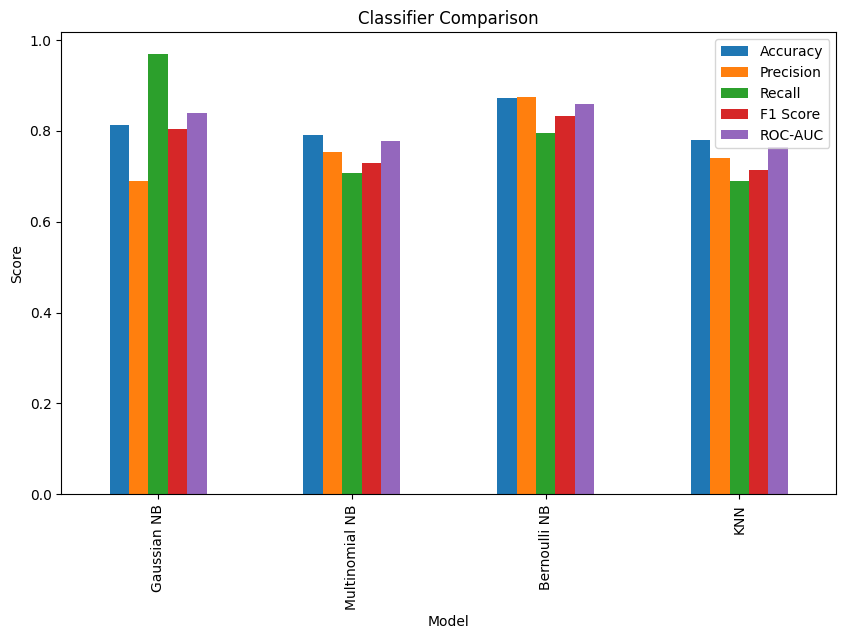

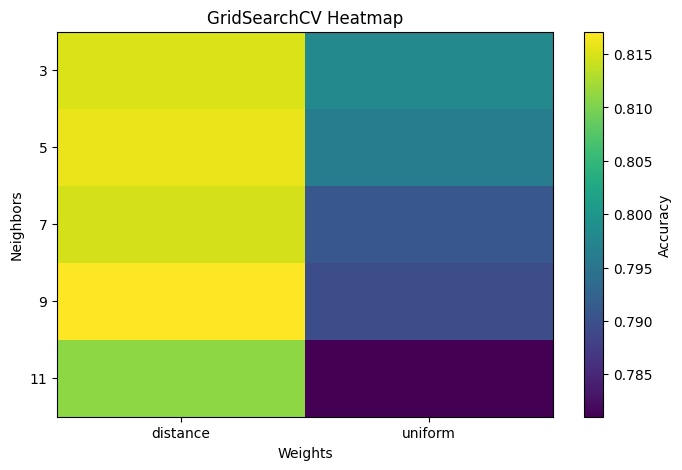

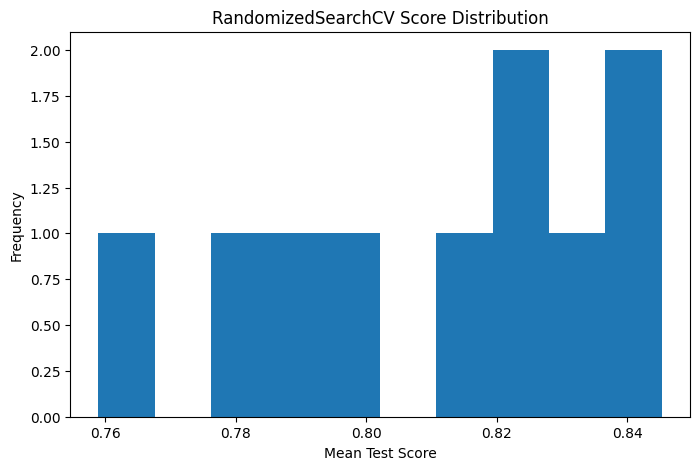

In [ ]:
models = {
    "Gaussian NB": gnb,
    "Multinomial NB": mnb,
    "Bernoulli NB": bnb,
    "KNN": knn
}

results = []
df_time = pd.DataFrame(time_results)
for name, model in models.items():

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, pred)
    })

comparison = pd.DataFrame(results)

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(axis="y")
plt.show()


comparison.plot(
    x="Model",
    y=["Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Precision Recall F1 Score")
plt.ylabel("Score")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"],comparison["ROC-AUC"])
plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.show()

cv_accuracy = {
    "Gaussian NB": gnb_scores.mean(),
    "Multinomial NB": mnb_scores.mean(),
    "Bernoulli NB": bnb_scores.mean(),
    "KNN": knn_scores.mean()
}

plt.figure(figsize=(8,5))
plt.bar(cv_accuracy.keys(),cv_accuracy.values())
plt.title("Cross Validation Accuracy")
plt.ylabel("Mean Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(df_time["Model"],df_time["Training Time (s)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(df_time["Model"],df_time["Prediction Time (s)"])
plt.title("Prediction Time Comparison")
plt.ylabel("Seconds")
plt.show()

for name, model, color in [
    ("Gaussian Naive Bayes", gnb, "Blues"),
    ("Multinomial Naive Bayes", mnb, "Greens"),
    ("Bernoulli Naive Bayes", bnb, "Purples"),
    ("KNN", knn, "Oranges")
]:

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap=color
    )

    plt.title(name + " Confusion Matrix")
    plt.show()

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_score = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test,y_score)

    plt.plot(fpr,tpr,label=name+" (AUC="+str(round(auc(fpr,tpr),2))+")")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_score=model.predict_proba(X_test)[:,1]

    precision,recall,_=precision_recall_curve(y_test,y_score)

    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curves")
plt.legend()
plt.show()

k_values=range(1,21)

accuracy=[]

for k in k_values:

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    accuracy.append(accuracy_score(y_test,pred))

plt.figure(figsize=(8,5))
plt.plot(k_values,accuracy,marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

comparison.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Classifier Comparison")
plt.ylabel("Score")
plt.show()

grid_results=pd.DataFrame(grid.cv_results_)

pivot=grid_results.pivot_table(
    values="mean_test_score",
    index="param_n_neighbors",
    columns="param_weights"
)

plt.figure(figsize=(8,5))
plt.imshow(pivot,cmap="viridis",aspect="auto")
plt.colorbar(label="Accuracy")
plt.xticks(range(len(pivot.columns)),pivot.columns)
plt.yticks(range(len(pivot.index)),pivot.index)
plt.xlabel("Weights")
plt.ylabel("Neighbors")
plt.title("GridSearchCV Heatmap")
plt.show()

random_results=pd.DataFrame(random.cv_results_)

plt.figure(figsize=(8,5))
plt.hist(random_results["mean_test_score"],bins=10)
plt.xlabel("Mean Test Score")
plt.ylabel("Frequency")
plt.title("RandomizedSearchCV Score Distribution")
plt.show()